<a href="https://colab.research.google.com/github/SebastianIWright/Financial-Models/blob/main/multi_asset_porfolio_risk_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   MULTI-ASSET PORTFOLIO RISK DASHBOARD  |  Quantitative Finance Research   ║
║   VaR · CVaR · Monte Carlo · Stress Testing · Greeks · Kupiec Backtest     ║
║   Comparable to: BlackRock Aladdin · MSCI RiskMetrics · Bloomberg PORT     ║
╚══════════════════════════════════════════════════════════════════════════════╝

GOOGLE COLAB NOTEBOOK

Author:  Sebastian Wright
Version: 1.0.0

═══════════════════════════════════════════════════════════════════════════════
PROJECT OVERVIEW
═══════════════════════════════════════════════════════════════════════════════
This notebook builds an institutional-grade Multi-Asset Portfolio Risk Dashboard
that computes, visualizes, and validates the primary risk metrics used by every
risk manager at every major asset manager, bank, and hedge fund.

Portfolio composition:
    Equities    (60%): SPY, QQQ, IWM, EFA, EEM
    Bonds       (25%): TLT, IEF
    Commodity   (10%): GLD
    Options      (5%): SPY covered call + protective put (Greeks-adjusted)

Core deliverables:
    1. Value at Risk (VaR): Historical Simulation, Parametric, Monte Carlo
    2. Expected Shortfall (CVaR/ES): tail loss beyond VaR
    3. Marginal VaR and Component VaR: per-position risk attribution
    4. Historical stress tests: 2008 GFC, COVID crash, 2022 rate shock
    5. Black-Scholes Greeks for options positions
    6. Kupiec POF backtesting: statistical validation of VaR model accuracy
    7. Rolling risk metrics: how VaR evolves over time
    8. 6-chart professional dashboard suitable for GitHub and interviews

REAL-WORLD FINANCE USE CASE
═══════════════════════════════════════════════════════════════════════════════
This dashboard replicates the morning risk report delivered to the CRO
(Chief Risk Officer) at every major institution:

    BlackRock:       Aladdin risk platform — computes VaR for $10T+ in AUM
    PIMCO:           Daily VaR reports for all fixed income portfolios
    Goldman Sachs:   Market Risk Management — daily 99% VaR by desk
    JPMorgan:        Basel III internal model approach (IMA) — regulatory VaR
    Citadel:         Real-time risk monitoring across all strategy pods
    Pension funds:   Funded status risk and liability-driven VaR

Basel III/IV requires banks to maintain regulatory capital based on VaR and
Stressed VaR. Every bank's risk department runs these calculations daily.

DATA SOURCES (Production)
═══════════════════════════════════════════════════════════════════════════════
    Yahoo Finance:  Historical prices for ETFs (SPY, QQQ, IWM, EFA, EEM,
                    TLT, IEF, GLD) — free, no API key required
    CBOE:           VIX for implied volatility term structure
    FRED:           Risk-free rate (3-month T-bill)

NOTE: This notebook includes a high-fidelity data generator that replicates
real ETF return properties including the 2020 COVID crash and 2022 rate shock.
The PRODUCTION BLOCK at the bottom of Cell 3 provides the live Yahoo Finance
fetch code — replace the generator with it when running in real-time.

FOLDER STRUCTURE (GitHub Repository)
═══════════════════════════════════════════════════════════════════════════════
    portfolio_risk_dashboard/
    ├── portfolio_risk_dashboard.ipynb    ← Main Colab notebook
    ├── README.md                         ← Project documentation
    ├── requirements.txt                  ← Dependencies
    ├── src/
    │   ├── data_pipeline.py             ← Data fetch and cleaning
    │   ├── var_models.py                ← VaR/CVaR implementations
    │   ├── stress_testing.py            ← Stress test scenarios
    │   ├── options_greeks.py            ← Black-Scholes Greeks
    │   ├── backtesting.py               ← Kupiec and Christoffersen tests
    │   └── visualizations.py           ← Dashboard charts
    └── outputs/
        ├── risk_dashboard.png
        ├── stress_test_report.png
        ├── var_backtest.png
        └── morning_var_report.pdf
"""

"\n╔══════════════════════════════════════════════════════════════════════════════╗\n║   MULTI-ASSET PORTFOLIO RISK DASHBOARD  |  Quantitative Finance Research   ║\n║   VaR · CVaR · Monte Carlo · Stress Testing · Greeks · Kupiec Backtest     ║\n║   Comparable to: BlackRock Aladdin · MSCI RiskMetrics · Bloomberg PORT     ║\n╚══════════════════════════════════════════════════════════════════════════════╝\n\nGOOGLE COLAB NOTEBOOK \n\nAuthor:  Sebastian Wright\nVersion: 1.0.0\n\n═══════════════════════════════════════════════════════════════════════════════\nPROJECT OVERVIEW\n═══════════════════════════════════════════════════════════════════════════════\nThis notebook builds an institutional-grade Multi-Asset Portfolio Risk Dashboard\nthat computes, visualizes, and validates the primary risk metrics used by every\nrisk manager at every major asset manager, bank, and hedge fund.\n\nPortfolio composition:\n    Equities    (60%): SPY, QQQ, IWM, EFA, EEM\n    Bonds       (25%): TLT, IEF\n    

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 ── ENVIRONMENT SETUP & LIBRARY INSTALLATION
# ═══════════════════════════════════════════════════════════════════════════════


# ── Colab Install Block (uncomment in Colab) ──────────────────────────────────
!pip install yfinance arch plotly kaleido -q


import warnings
warnings.filterwarnings('ignore')

# ── Standard Library ──────────────────────────────────────────────────────────
import os
from datetime import datetime, date
from typing import Dict, List, Tuple, Optional

# ── Scientific Computing ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
from scipy.linalg import cholesky
from scipy.optimize import brentq

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter
import matplotlib.dates as mdates
import seaborn as sns

# ── Optional: GARCH for volatility forecasting ────────────────────────────────
try:
    from arch import arch_model
    HAS_ARCH = True
except ImportError:
    HAS_ARCH = False
    print("  Note: arch not installed — GARCH vol forecasting disabled")

try:
    from IPython.display import display, HTML
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Global Style ──────────────────────────────────────────────────────────────
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#e6edf3',
    'axes.titlecolor':   '#e6edf3',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#e6edf3',
    'grid.color':        '#21262d',
    'grid.alpha':        0.5,
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'legend.fontsize':   9,
    'figure.titlesize':  14,
})

COLORS = {
    'equity':    '#3fb950',
    'bond':      '#388bfd',
    'commodity': '#e3b341',
    'option':    '#d2a8ff',
    'danger':    '#f85149',
    'warning':   '#e3b341',
    'safe':      '#3fb950',
    'neutral':   '#8b949e',
}

print("=" * 65)
print("  MULTI-ASSET PORTFOLIO RISK DASHBOARD")
print("=" * 65)
print(f"  NumPy:       {np.__version__}")
print(f"  Pandas:      {pd.__version__}")
print(f"  Matplotlib:  {matplotlib.__version__}")
print(f"  ARCH/GARCH:  {'available' if HAS_ARCH else 'not installed'}")
print("=" * 65)
print("  ✓ Environment ready. Building institutional risk dashboard.")
print("=" * 65)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.8 MB/s eta 0:00:00
  MULTI-ASSET PORTFOLIO RISK DASHBOARD
  NumPy:       2.0.2
  Pandas:      2.2.2
  Matplotlib:  3.10.0
  ARCH/GARCH:  available
  ✓ Environment ready. Building institutional risk dashboard.


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 ── PORTFOLIO CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════
# PURPOSE: Define portfolio holdings, options positions, risk parameters,
# and stress test scenarios. All tunable parameters live here.

# ── Date Range ────────────────────────────────────────────────────────────────
START_DATE = '2019-01-02'
END_DATE   = '2024-12-31'

# ── Portfolio Holdings ────────────────────────────────────────────────────────
# Weights represent allocation fractions (sum to 1.0)
# Notional represents $1,000,000 total portfolio
PORTFOLIO_NOTIONAL = 1_000_000  # $1M portfolio

HOLDINGS = {
    'SPY': {'class':'equity',    'weight':0.20, 'name':'SPDR S&P 500 ETF'},
    'QQQ': {'class':'equity',    'weight':0.15, 'name':'Invesco QQQ Trust'},
    'IWM': {'class':'equity',    'weight':0.10, 'name':'iShares Russell 2000'},
    'EFA': {'class':'equity',    'weight':0.10, 'name':'iShares MSCI EAFE'},
    'EEM': {'class':'equity',    'weight':0.05, 'name':'iShares MSCI EM'},
    'TLT': {'class':'bond',      'weight':0.15, 'name':'iShares 20Y Treasury'},
    'IEF': {'class':'bond',      'weight':0.10, 'name':'iShares 7-10Y Treasury'},
    'GLD': {'class':'commodity', 'weight':0.10, 'name':'SPDR Gold Trust'},
}

# ── Options Overlay ───────────────────────────────────────────────────────────
# Options positions as % of notional (5% total)
# Modeled as Black-Scholes positions with real-time Greeks
OPTIONS_POSITIONS = [
    {
        'ticker':      'SPY',
        'type':        'call',
        'weight':       0.03,        # 3% of notional
        'S':            460,         # Current underlying price
        'K':            480,         # Strike price (OTM call = covered call)
        'T':            45/252,      # 45 days to expiry
        'r':            0.05,        # Risk-free rate
        'sigma':        0.18,        # Implied volatility
        'position':    -1,           # Short (covered call: reduces upside, earns premium)
        'contracts':    10,          # Number of contracts (100 shares each)
        'description': 'Short OTM Call (Covered Call — income generation)',
    },
    {
        'ticker':      'SPY',
        'type':        'put',
        'weight':       0.02,        # 2% of notional
        'S':            460,
        'K':            440,         # Strike price (OTM put = protective)
        'T':            45/252,
        'r':            0.05,
        'sigma':        0.20,        # Puts trade at higher IV (skew)
        'position':     1,           # Long (protective put: downside insurance)
        'contracts':    5,
        'description': 'Long OTM Put (Protective Put — tail risk hedge)',
    },
]

# ── Risk Parameters ───────────────────────────────────────────────────────────
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]  # Standard risk reporting levels
MC_SIMULATIONS    = 50_000              # Monte Carlo sample size
ROLLING_WINDOW    = 252                 # Rolling VaR lookback (1 year)
RISK_FREE_RATE    = 0.05                # Current risk-free rate (annualized)

# ── Stress Test Scenarios ─────────────────────────────────────────────────────
# Annual return shocks applied to each asset class
# Source: actual historical drawdowns from Bloomberg / FRED
STRESS_SCENARIOS = {
    '2008 GFC': {
        'equity':    -0.45,   # S&P 500 peak-to-trough: -57%, 9-month horizon
        'bond':       0.15,   # Treasuries rallied as flight-to-quality
        'commodity': -0.30,   # Crude oil crashed, gold was mixed
        'description': 'Global Financial Crisis (Sep 2008 – Mar 2009)',
    },
    'COVID Crash': {
        'equity':    -0.34,   # Feb 20 – Mar 23 2020: 33 calendar days
        'bond':       0.08,   # Initial bond rally, later reversal
        'commodity': -0.15,
        'description': 'COVID-19 Crash (Feb–Mar 2020)',
    },
    '2022 Rate Shock': {
        'equity':    -0.20,   # S&P 500: -19.4% in 2022
        'bond':      -0.25,   # TLT: -31% in 2022 (worst bond year since 1788)
        'commodity':  0.20,   # Commodities rose on inflation shock
        'description': '2022 Rate Shock (Fastest Fed hiking cycle since 1980s)',
    },
    'Dot-Com Bust': {
        'equity':    -0.38,   # Nasdaq -78%, S&P 500 -49%
        'bond':       0.12,
        'commodity': -0.05,
        'description': 'Dot-Com Bust (Mar 2000 – Oct 2002)',
    },
    'Flash Crash': {
        'equity':    -0.09,   # May 6, 2010: intraday -9.2% in S&P 500
        'bond':       0.03,
        'commodity': -0.03,
        'description': 'Flash Crash (May 6, 2010 — single day shock)',
    },
    'Euro Crisis': {
        'equity':    -0.22,
        'bond':       0.08,
        'commodity': -0.10,
        'description': 'European Debt Crisis (May–Jun 2012)',
    },
}

EQUITY_TICKERS    = [k for k,v in HOLDINGS.items() if v['class']=='equity']
BOND_TICKERS      = [k for k,v in HOLDINGS.items() if v['class']=='bond']
COMMODITY_TICKERS = [k for k,v in HOLDINGS.items() if v['class']=='commodity']
ALL_TICKERS       = list(HOLDINGS.keys())
WEIGHTS           = np.array([HOLDINGS[t]['weight'] for t in ALL_TICKERS])
WEIGHTS           = WEIGHTS / WEIGHTS.sum()  # Normalize

print(f"✓ Portfolio configuration loaded:")
print(f"  Holdings:          {len(HOLDINGS)} positions")
print(f"  Options overlay:   {len(OPTIONS_POSITIONS)} contracts")
print(f"  Total notional:    ${PORTFOLIO_NOTIONAL:,.0f}")
print(f"  MC simulations:    {MC_SIMULATIONS:,}")
print(f"  Stress scenarios:  {len(STRESS_SCENARIOS)}")
print(f"\n  Weight allocation:")
for ticker, holding in HOLDINGS.items():
    print(f"    {ticker:5s} ({holding['class']:9s}): {holding['weight']:.0%}  {holding['name']}")


✓ Portfolio configuration loaded:
  Holdings:          8 positions
  Options overlay:   2 contracts
  Total notional:    $1,000,000
  MC simulations:    50,000
  Stress scenarios:  6

  Weight allocation:
    SPY   (equity   ): 20%  SPDR S&P 500 ETF
    QQQ   (equity   ): 15%  Invesco QQQ Trust
    IWM   (equity   ): 10%  iShares Russell 2000
    EFA   (equity   ): 10%  iShares MSCI EAFE
    EEM   (equity   ): 5%  iShares MSCI EM
    TLT   (bond     ): 15%  iShares 20Y Treasury
    IEF   (bond     ): 10%  iShares 7-10Y Treasury
    GLD   (commodity): 10%  SPDR Gold Trust


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 (REPLACEMENT) ── DATA COLLECTION PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE FROM ORIGINAL: The COVID crash injection now uses asset-specific
# shock magnitudes (calibrated to real historical dispersion) instead of a
# single uniform shock applied to all equities. This makes Upgrade 2's
# historical scenario replay meaningfully different from a simple factor
# shock — in reality, small caps (IWM) and emerging markets (EEM) fell
# further than large-cap US equities (SPY) during COVID, and this
# dispersion is exactly what a factor-shock stress test cannot capture.

class PortfolioDataPipeline:
    """
    Calibrated synthetic price generator for multi-asset risk research.

    Generates 6 years of daily returns with:
        - Realistic cross-asset correlation structure
        - Student-t innovations for fat tails (df=5)
        - Asset-specific historical crisis dispersion (not uniform shocks)

    For production use: swap generate() for fetch_from_yahoo().
    """

    def __init__(self, holdings: Dict, start: str, end: str):
        self.holdings = holdings
        self.dates    = pd.bdate_range(start=start, end=end)
        self.n        = len(self.dates)
        self.tickers  = list(holdings.keys())
        self.n_assets = len(self.tickers)

        self.annual_mus  = {
            'SPY': 0.11, 'QQQ': 0.16, 'IWM': 0.07, 'EFA': 0.05, 'EEM': 0.04,
            'TLT': 0.02, 'IEF': 0.02, 'GLD': 0.08,
        }
        self.annual_vols = {
            'SPY': 0.16, 'QQQ': 0.22, 'IWM': 0.20, 'EFA': 0.17, 'EEM': 0.22,
            'TLT': 0.14, 'IEF': 0.07, 'GLD': 0.15,
        }

        # ── Asset-specific crisis dispersion (NEW) ─────────────────────────
        # Real historical peak-to-trough returns during COVID (Feb 20 - Mar 23, 2020)
        # by asset. Small caps and EM fell further than large-cap US equities.
        # Bonds rallied unevenly — long duration (TLT) more than short (IEF).
        self.covid_shocks = {
            'SPY': -0.32,   # S&P 500: actual was ~-34%, close approximation
            'QQQ': -0.30,   # Nasdaq fell slightly less initially (mega-cap resilience)
            'IWM': -0.40,   # Russell 2000 (small caps): fell further, less liquid
            'EFA': -0.36,   # Developed international: similar to US, slight lag
            'EEM': -0.42,   # Emerging markets: hit hardest (EM outflows, dollar strength)
            'TLT': 0.10,    # Long Treasuries: strong flight-to-quality rally
            'IEF': 0.06,    # Intermediate Treasuries: smaller rally (less duration)
            'GLD': -0.12,   # Gold: counterintuitively fell initially (margin call liquidations)
        }
        self.rate_shock_2022 = {
            # Real approximate 2022 full-year ETF total returns.
            # 2022 was a uniquely bad year: BOTH equities and bonds fell
            # together (correlation broke down), which is precisely why
            # it's included as a stress scenario — it invalidates the
            # classic 60/40 diversification assumption.
            'SPY': -0.182, 'QQQ': -0.326, 'IWM': -0.205, 'EFA': -0.145,
            'EEM': -0.201, 'TLT': -0.312, 'IEF': -0.152, 'GLD': -0.001,
        }

    def _build_correlation_matrix(self) -> np.ndarray:
        """Build realistic cross-asset correlation matrix."""
        n = self.n_assets
        corr = np.eye(n)
        idx  = {t: i for i, t in enumerate(self.tickers)}

        for t1 in ['SPY','QQQ','IWM','EFA','EEM']:
            for t2 in ['SPY','QQQ','IWM','EFA','EEM']:
                if t1 != t2:
                    corr[idx[t1], idx[t2]] = 0.75

        corr[idx['TLT'], idx['IEF']] = corr[idx['IEF'], idx['TLT']] = 0.65

        for eq in ['SPY','QQQ','IWM','EFA','EEM']:
            corr[idx[eq], idx['TLT']] = corr[idx['TLT'], idx[eq]] = -0.30
            corr[idx[eq], idx['IEF']] = corr[idx['IEF'], idx[eq]] = -0.25

        for eq in ['SPY','QQQ','IWM','EFA','EEM']:
            corr[idx[eq], idx['GLD']] = corr[idx['GLD'], idx[eq]] = 0.05

        corr[idx['TLT'], idx['GLD']] = corr[idx['GLD'], idx['TLT']] = 0.15
        corr[idx['IEF'], idx['GLD']] = corr[idx['GLD'], idx['IEF']] = 0.10

        eigvals, eigvecs = np.linalg.eigh(corr)
        eigvals = np.maximum(eigvals, 1e-8)
        return eigvecs @ np.diag(eigvals) @ eigvecs.T

    def generate(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Generate correlated daily return and price DataFrames."""
        corr_pd = self._build_correlation_matrix()
        L       = cholesky(corr_pd, lower=True)

        Z = stats.t.rvs(df=5, size=(self.n, self.n_assets))
        Z = Z / np.sqrt(5/3)

        corr_z     = Z @ L.T
        daily_mus  = np.array([self.annual_mus[t]  / 252 for t in self.tickers])
        daily_vols = np.array([self.annual_vols[t] / np.sqrt(252) for t in self.tickers])

        raw_rets = daily_mus + corr_z * daily_vols

        # ── COVID crash: asset-specific shocks (NEW — replaces uniform shock) ──
        covid_mask = (self.dates >= '2020-02-20') & (self.dates <= '2020-03-23')
        n_covid_days = covid_mask.sum()
        if n_covid_days > 0:
            for i, t in enumerate(self.tickers):
                # Convert target cumulative shock into an equivalent daily
                # compounding rate: (1+total)^(1/n_days) - 1
                total_shock  = self.covid_shocks[t]
                daily_shock  = (1 + total_shock) ** (1 / n_covid_days) - 1
                # Blend the calibrated shock with existing noise (50% weight)
                # so days still have some idiosyncratic variation, not
                # perfectly identical daily returns
                raw_rets[covid_mask, i] = (
                    daily_shock + raw_rets[covid_mask, i] * 0.5
                )

        # ── 2022 rate shock: asset-specific full-year replacement ──────────────
        # Unlike COVID (a 23-day acute shock), 2022 was a persistent full-year
        # regime. We calibrate each asset to its actual approximate 2022 return
        # using the same technique as COVID: convert the annual target into an
        # equivalent daily compounding rate, blended with existing noise so
        # daily variation persists.
        rate_mask = (self.dates >= '2022-01-01') & (self.dates <= '2022-12-31')
        n_rate_days = rate_mask.sum()
        if n_rate_days > 0:
            for i, t in enumerate(self.tickers):
                if t in self.rate_shock_2022:
                    total_shock = self.rate_shock_2022[t]
                    daily_shock = (1 + total_shock) ** (1 / n_rate_days) - 1
                    raw_rets[rate_mask, i] = (
                        daily_shock + raw_rets[rate_mask, i] * 0.5
                    )

        raw_rets = np.clip(raw_rets, -0.15, 0.15)

        ret_df   = pd.DataFrame(raw_rets, index=self.dates, columns=self.tickers)
        price_df = (1 + ret_df).cumprod() * 100

        return ret_df, price_df

    def fetch_from_yahoo(self, start: str = START_DATE,
                          end: str = END_DATE) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """PRODUCTION: Fetch live ETF data from Yahoo Finance."""
        import yfinance as yf
        prices = {}
        for ticker in self.tickers:
            try:
                raw = yf.download(ticker, start=start, end=end,
                                   auto_adjust=True, progress=False)
                if isinstance(raw.columns, pd.MultiIndex):
                    prices[ticker] = raw[('Close', ticker)]
                else:
                    prices[ticker] = raw['Close']
                print(f"  ✓ {ticker}: {len(prices[ticker])} days")
            except Exception as e:
                print(f"  ✗ {ticker} failed: {e}")

        price_df = pd.DataFrame(prices).ffill().dropna()
        ret_df   = np.log(price_df).diff().dropna()
        return ret_df, price_df


# ── Run Data Pipeline ─────────────────────────────────────────────────────────
print("Generating portfolio data...")
pipeline = PortfolioDataPipeline(HOLDINGS, START_DATE, END_DATE)
ret_df, price_df = pipeline.generate()

port_rets = (ret_df * WEIGHTS).sum(axis=1)

print(f"\n{'─'*60}")
print(f"  Dataset: {len(ret_df)} trading days | {len(ALL_TICKERS)} assets")
print(f"  Date range: {ret_df.index[0].strftime('%b %Y')} → {ret_df.index[-1].strftime('%b %Y')}")
print(f"\n  Individual Asset Statistics (Annualized):")
print(f"  {'Ticker':6s} {'Class':10s} {'Return':>8s} {'Vol':>8s} {'Sharpe':>8s} {'MaxDD':>8s}")
print(f"  {'─'*54}")
for ticker in ALL_TICKERS:
    r   = ret_df[ticker]
    ar  = r.mean() * 252
    av  = r.std() * np.sqrt(252)
    sr  = (ar - RISK_FREE_RATE) / av if av > 0 else 0
    cum = (1 + r).cumprod()
    mdd = ((cum / cum.cummax()) - 1).min()
    cls = HOLDINGS[ticker]['class']
    print(f"  {ticker:6s} {cls:10s} {ar:8.2%} {av:8.2%} {sr:8.3f} {mdd:8.2%}")

print(f"\n  Portfolio Statistics (Annualized):")
p_ann_ret = port_rets.mean() * 252
p_ann_vol = port_rets.std() * np.sqrt(252)
p_sharpe  = (p_ann_ret - RISK_FREE_RATE) / p_ann_vol
p_cum     = (1 + port_rets).cumprod()
p_mdd     = ((p_cum / p_cum.cummax()) - 1).min()
print(f"    Ann. Return:   {p_ann_ret:.2%}")
print(f"    Ann. Vol:      {p_ann_vol:.2%}")
print(f"    Sharpe Ratio:  {p_sharpe:.3f}")
print(f"    Max Drawdown:  {p_mdd:.2%}")

# ── Verify calibration of injected shocks ─────────────────────────────────────
covid_mask_check = (ret_df.index >= '2020-02-20') & (ret_df.index <= '2020-03-23')
covid_port_return = (1 + port_rets[covid_mask_check]).prod() - 1
print(f"\n  Portfolio return during COVID window (Feb 20 - Mar 23, 2020): "
      f"{covid_port_return:.2%}")
print(f"  (Diversified portfolio loses less than pure equity's ~-34%)")
print(f"\n✓ Data pipeline complete.")



Generating portfolio data...

────────────────────────────────────────────────────────────
  Dataset: 1565 trading days | 8 assets
  Date range: Jan 2019 → Dec 2024

  Individual Asset Statistics (Annualized):
  Ticker Class        Return      Vol   Sharpe    MaxDD
  ──────────────────────────────────────────────────────
  SPY    equity        2.85%   14.75%   -0.146  -35.48%
  QQQ    equity        5.29%   20.40%    0.014  -41.59%
  IWM    equity       -7.04%   18.44%   -0.653  -55.00%
  EFA    equity       -3.79%   15.75%   -0.558  -43.81%
  EEM    equity      -11.33%   20.81%   -0.785  -62.48%
  TLT    bond         -2.51%   13.44%   -0.559  -42.80%
  IEF    bond         -1.95%    6.47%   -1.074  -21.31%
  GLD    commodity    -1.68%   14.33%   -0.467  -44.39%

  Portfolio Statistics (Annualized):
    Ann. Return:   -1.08%
    Ann. Vol:      9.71%
    Sharpe Ratio:  -0.626
    Max Drawdown:  -29.32%

  Portfolio return during COVID window (Feb 20 - Mar 23, 2020): -23.60%
  (Diversified

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 (REPLACEMENT) ── VaR ENGINE: HISTORICAL, PARAMETRIC, MONTE CARLO, GARCH
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE FROM ORIGINAL: Adds garch_var() method — Upgrade 1.
#
# WHY THIS MATTERS:
# The original three VaR methods all assume CONSTANT volatility — either
# the full-sample historical volatility (Historical/Parametric) or a single
# covariance matrix estimate (Monte Carlo). Real markets exhibit VOLATILITY
# CLUSTERING: high-volatility days cluster together (crisis periods), and
# low-volatility days cluster together (calm periods). A constant-vol VaR
# model is too conservative in calm periods and too permissive right before
# a volatility regime shift.
#
# GARCH(1,1) models volatility as a function of the previous period's
# volatility AND the previous period's squared return shock:
#     σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
# This lets VaR adapt day-to-day as market conditions change, rather than
# using one static number computed across 6 years of history.

class VaREngine:
    """
    Institutional VaR computation engine.

    Implements Historical Simulation, Parametric, Monte Carlo, and
    GARCH(1,1)-based VaR — the four methodologies used across the
    industry, each representing a different assumption about how
    volatility behaves.
    """

    def __init__(self, returns: pd.Series, weights: np.ndarray,
                 ret_df: pd.DataFrame, notional: float = 1_000_000):
        self.returns  = returns
        self.weights  = weights
        self.ret_df   = ret_df
        self.notional = notional
        self.n        = len(returns)
        self._garch_fitted = None  # Cache the fitted model

    def historical_var(self, confidence: float = 0.95) -> Dict:
        """Historical Simulation VaR and CVaR — see original docstring."""
        alpha    = 1 - confidence
        var      = np.percentile(self.returns, alpha * 100)
        cvar     = self.returns[self.returns <= var].mean()
        var_dollar  = abs(var) * self.notional
        cvar_dollar = abs(cvar) * self.notional

        return {
            'method':       'Historical Simulation',
            'confidence':   confidence,
            'var_pct':      var,
            'cvar_pct':     cvar,
            'var_dollar':   var_dollar,
            'cvar_dollar':  cvar_dollar,
            'n_violations': (self.returns < var).sum(),
            'expected_viol':int(self.n * alpha),
        }

    def parametric_var(self, confidence: float = 0.95) -> Dict:
        """Parametric (Delta-Normal) VaR — assumes constant normal volatility."""
        alpha  = 1 - confidence
        z      = stats.norm.ppf(alpha)
        mu_p   = self.returns.mean()
        sig_p  = self.returns.std()

        var    = mu_p + z * sig_p
        cvar   = mu_p - sig_p * stats.norm.pdf(-z) / alpha

        return {
            'method':      'Parametric (Delta-Normal)',
            'confidence':  confidence,
            'var_pct':     var,
            'cvar_pct':    cvar,
            'var_dollar':  abs(var) * self.notional,
            'cvar_dollar': abs(cvar) * self.notional,
            'portfolio_vol': sig_p * np.sqrt(252),
            'z_critical':  abs(z),
        }

    def monte_carlo_var(self, confidence: float = 0.95,
                         n_sim: int = 50_000) -> Dict:
        """Monte Carlo VaR via Cholesky-correlated simulation."""
        cov_matrix = self.ret_df.cov().values

        try:
            L = cholesky(cov_matrix, lower=True)
        except Exception:
            eigv, eigvec = np.linalg.eigh(cov_matrix)
            eigv = np.maximum(eigv, 1e-8)
            cov_matrix = eigvec @ np.diag(eigv) @ eigvec.T
            L = cholesky(cov_matrix, lower=True)

        mu_daily = self.ret_df.mean().values
        Z        = np.random.randn(n_sim, len(self.weights))
        sim_rets = mu_daily + Z @ L.T

        port_sim = sim_rets @ self.weights
        alpha    = 1 - confidence
        var      = np.percentile(port_sim, alpha * 100)
        cvar     = port_sim[port_sim <= var].mean()

        return {
            'method':       'Monte Carlo',
            'confidence':   confidence,
            'var_pct':      var,
            'cvar_pct':     cvar,
            'var_dollar':   abs(var) * self.notional,
            'cvar_dollar':  abs(cvar) * self.notional,
            'n_simulations': n_sim,
            'simulated_returns': port_sim,
        }

    def garch_var(self, confidence: float = 0.95,
                   refit: bool = False) -> Dict:
        """
        GARCH(1,1) VaR — Upgrade 1.

        Fits a GARCH(1,1) model with Student-t innovations to the portfolio
        return series, forecasts next-period conditional volatility, and
        computes VaR using that FORWARD-LOOKING vol estimate rather than
        the flat historical standard deviation.

        Model specification:
            r_t = μ + ε_t
            ε_t = σ_t · z_t,   z_t ~ Student-t(ν)
            σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}

        α + β close to 1 indicates strong volatility persistence — once
        vol rises, it tends to stay elevated for a while before mean-reverting.
        This is exactly the phenomenon a constant-volatility model cannot
        capture, and exactly why real bank risk models use GARCH-family
        approaches rather than simple historical standard deviation.

        Requires the `arch` package: pip install arch
        """
        if not HAS_ARCH:
            return {
                'method': 'GARCH(1,1)', 'error': 'arch package not installed',
                'var_pct': np.nan, 'cvar_pct': np.nan,
                'var_dollar': np.nan, 'cvar_dollar': np.nan,
            }

        # Fit GARCH(1,1) with Student-t innovations (captures fat tails
        # AND volatility clustering simultaneously — the two key stylized
        # facts about financial returns this notebook has discussed)
        # Returns scaled by 100 for numerical stability (arch package convention)
        if self._garch_fitted is None or refit:
            model = arch_model(self.returns * 100, vol='Garch',
                               p=1, q=1, dist='t', mean='Constant')
            self._garch_fitted = model.fit(disp='off', show_warning=False)

        fitted = self._garch_fitted

        # Forecast next-period conditional volatility
        forecast        = fitted.forecast(horizon=1, reindex=False)
        conditional_var = forecast.variance.values[-1, 0] / (100**2)  # rescale
        conditional_vol = np.sqrt(conditional_var)

        # Student-t critical value at the fitted degrees of freedom
        nu = fitted.params['nu']
        z_t = stats.t.ppf(1 - confidence, df=nu)
        # Scale t-distribution to match the conditional variance
        # (a standard t(nu) has variance nu/(nu-2), not 1)
        t_scale = np.sqrt((nu - 2) / nu) if nu > 2 else 1.0

        mu = fitted.params['mu'] / 100

        var  = mu + z_t * t_scale * conditional_vol
        # CVaR for Student-t: analytical formula
        cvar = mu - conditional_vol * t_scale * (
            stats.t.pdf(z_t, df=nu) / (1-confidence) *
            (nu + z_t**2) / (nu - 1)
        )

        return {
            'method':               'GARCH(1,1)',
            'confidence':           confidence,
            'var_pct':              var,
            'cvar_pct':             cvar,
            'var_dollar':           abs(var) * self.notional,
            'cvar_dollar':          abs(cvar) * self.notional,
            'conditional_vol_daily':      conditional_vol,
            'conditional_vol_annualized': conditional_vol * np.sqrt(252),
            'unconditional_vol_annualized': self.returns.std() * np.sqrt(252),
            'garch_alpha':          fitted.params['alpha[1]'],
            'garch_beta':           fitted.params['beta[1]'],
            'persistence':          fitted.params['alpha[1]'] + fitted.params['beta[1]'],
            'degrees_of_freedom':   nu,
            'fitted_model':         fitted,
        }

    def garch_conditional_vol_series(self) -> pd.Series:
        """
        Return the full in-sample conditional volatility path from the
        fitted GARCH model — this is what Panel showing "current risk regime"
        in the dashboard will plot. Shows vol spiking during COVID/2022
        and decaying afterward, unlike the flat historical vol line.
        """
        if not HAS_ARCH:
            return pd.Series(dtype=float)

        if self._garch_fitted is None:
            self.garch_var()  # triggers fit

        cond_vol = np.sqrt(self._garch_fitted.conditional_volatility**2) / 100
        cond_vol.index = self.returns.index
        return cond_vol * np.sqrt(252)  # annualized

    def marginal_var(self, confidence: float = 0.95,
                      delta: float = 0.001) -> Dict:
        """Marginal VaR and Component VaR per position."""
        base_var = np.percentile(self.returns, (1 - confidence) * 100)

        marginal  = {}
        component = {}
        for i, ticker in enumerate(self.ret_df.columns):
            w_perturbed = self.weights.copy()
            w_perturbed[i] += delta
            w_perturbed /= w_perturbed.sum()
            port_perturbed = (self.ret_df * w_perturbed).sum(axis=1)
            var_perturbed  = np.percentile(port_perturbed, (1-confidence)*100)

            marginal_i  = (var_perturbed - base_var) / delta
            marginal[ticker]  = marginal_i
            component[ticker] = marginal_i * self.weights[i]

        return {
            'marginal_var':    marginal,
            'component_var':   component,
            'portfolio_var':   base_var,
            'var_dollar':      abs(base_var) * self.notional,
            'component_dollar': {
                k: abs(v) * self.notional for k, v in component.items()
            },
        }

    def rolling_var(self, window: int = 252,
                     confidence: float = 0.95) -> pd.Series:
        """Rolling historical VaR — shows how risk evolves over time."""
        return self.returns.rolling(window).quantile(1 - confidence)

    def run_all(self) -> Dict:
        """Run all VaR methods at all confidence levels and return results dict."""
        results = {}
        for cl in CONFIDENCE_LEVELS:
            cl_key = f"{int(cl*100)}%"
            results[cl_key] = {
                'historical':  self.historical_var(cl),
                'parametric':  self.parametric_var(cl),
                'monte_carlo': self.monte_carlo_var(cl, MC_SIMULATIONS),
                'garch':       self.garch_var(cl),
            }
        results['marginal']  = self.marginal_var()
        results['rolling_95'] = self.rolling_var(ROLLING_WINDOW, 0.95)
        results['rolling_99'] = self.rolling_var(ROLLING_WINDOW, 0.99)
        results['garch_conditional_vol'] = self.garch_conditional_vol_series()
        return results


# ── Run VaR Engine ────────────────────────────────────────────────────────────
print("=" * 60)
print("  VaR ENGINE — COMPUTING ALL METHODS (INCL. GARCH)")
print("=" * 60)

var_engine  = VaREngine(port_rets, WEIGHTS, ret_df, PORTFOLIO_NOTIONAL)
var_results = var_engine.run_all()

print(f"\n  PORTFOLIO VaR SUMMARY  (Portfolio Size: ${PORTFOLIO_NOTIONAL:,.0f})")
print(f"  {'─'*70}")
print(f"  {'Method':25s} {'CL':>5s} {'VaR (%)':>8s} {'VaR ($)':>12s} {'CVaR (%)':>9s} {'CVaR ($)':>12s}")
print(f"  {'─'*70}")

for cl in CONFIDENCE_LEVELS:
    cl_key = f"{int(cl*100)}%"
    for method_key in ['historical', 'parametric', 'monte_carlo', 'garch']:
        r    = var_results[cl_key][method_key]
        name = r['method'][:24]
        if np.isnan(r['var_pct']):
            print(f"  {name:25s} {cl_key:>5s}  (unavailable — install arch)")
            continue
        print(f"  {name:25s} {cl_key:>5s} "
              f"{r['var_pct']:8.3%} "
              f"${r['var_dollar']:>10,.0f} "
              f"{r['cvar_pct']:9.3%} "
              f"${r['cvar_dollar']:>10,.0f}")
    print(f"  {'·'*70}")

# ── GARCH-specific diagnostics ─────────────────────────────────────────────────
garch_95 = var_results['95%']['garch']
if not np.isnan(garch_95.get('var_pct', np.nan)):
    print(f"\n  GARCH(1,1) MODEL DIAGNOSTICS:")
    print(f"  {'─'*50}")
    print(f"    Alpha (shock reaction):     {garch_95['garch_alpha']:.4f}")
    print(f"    Beta (vol persistence):     {garch_95['garch_beta']:.4f}")
    print(f"    Persistence (α+β):          {garch_95['persistence']:.4f}")
    print(f"    Degrees of freedom (t-dist): {garch_95['degrees_of_freedom']:.2f}")
    print(f"    Current conditional vol:     {garch_95['conditional_vol_annualized']:.2%} (annualized)")
    print(f"    Unconditional (historical):  {garch_95['unconditional_vol_annualized']:.2%} (annualized)")

    vol_ratio = garch_95['conditional_vol_annualized'] / garch_95['unconditional_vol_annualized']
    if vol_ratio > 1.1:
        regime = "ELEVATED — current vol above long-run average, VaR should be higher than static estimate"
    elif vol_ratio < 0.9:
        regime = "CALM — current vol below long-run average, VaR should be lower than static estimate"
    else:
        regime = "NORMAL — current vol near long-run average"
    print(f"\n    Current regime: {regime}")
    print(f"    (Ratio of conditional/unconditional vol: {vol_ratio:.2f}x)")

print(f"\n  COMPONENT VaR (95%) — Risk Attribution:")
comp_var = var_results['marginal']['component_var']
total_var = var_results['marginal']['portfolio_var']
for ticker, cv in sorted(comp_var.items(), key=lambda x: x[1]):
    pct_of_total = cv / total_var * 100 if total_var != 0 else 0
    bar = '█' * max(0, int(abs(pct_of_total) / 2))
    print(f"    {ticker:5s}: {cv:7.4f}  ({abs(pct_of_total):5.1f}% of total VaR)  {bar}")

print(f"\n✓ VaR computation complete (4 methodologies).")


  VaR ENGINE — COMPUTING ALL METHODS (INCL. GARCH)

  PORTFOLIO VaR SUMMARY  (Portfolio Size: $1,000,000)
  ──────────────────────────────────────────────────────────────────────
  Method                       CL  VaR (%)      VaR ($)  CVaR (%)     CVaR ($)
  ──────────────────────────────────────────────────────────────────────
  Historical Simulation       90%  -0.743% $     7,425   -1.130% $    11,303
  Parametric (Delta-Normal    90%  -0.788% $     7,881   -1.078% $    10,777
  Monte Carlo                 90%  -0.789% $     7,892   -1.077% $    10,774
  GARCH(1,1)                  90%  -0.861% $     8,611   -1.261% $    12,610
  ······································································
  Historical Simulation       95%  -1.060% $    10,603   -1.367% $    13,674
  Parametric (Delta-Normal    95%  -1.010% $    10,103   -1.266% $    12,659
  Monte Carlo                 95%  -1.011% $    10,108   -1.266% $    12,665
  GARCH(1,1)                  95%  -1.142% $    11,416   

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 ── OPTIONS GREEKS ENGINE
# ═══════════════════════════════════════════════════════════════════════════════
# PURPOSE: Compute Black-Scholes Greeks for the options overlay positions.
# Greeks adjust the portfolio's effective market exposure — a short call
# reduces effective equity delta, a long put adds negative delta exposure.
#
# GREEKS EXPLAINED:
#   Delta (Δ): Change in option price per $1 change in underlying
#              → Effective stock position (delta = 1 = equivalent to owning 1 share)
#   Gamma (Γ): Rate of change of delta per $1 change in underlying
#              → Convexity of the option position
#   Vega  (ν): Change in option price per 1% change in implied volatility
#              → Volatility exposure
#   Theta (Θ): Change in option price per day (time decay)
#              → Cost of holding an option (negative for long positions)
#   Rho   (ρ): Change in option price per 1% change in risk-free rate

class OptionsGreeksEngine:
    """
    Black-Scholes options Greeks computation for portfolio risk adjustment.

    Computes all 5 Greeks for each option position and aggregates to
    portfolio-level Greeks-adjusted exposures. This is the standard
    approach at every derivatives desk and risk management group.
    """

    @staticmethod
    def d1_d2(S: float, K: float, T: float, r: float, sigma: float):
        """
        Compute Black-Scholes d1 and d2 parameters.
            d1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)
            d2 = d1 - σ√T
        """
        if T <= 0 or sigma <= 0:
            return 0, 0
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return d1, d2

    def compute_greeks(self, S: float, K: float, T: float, r: float,
                        sigma: float, option_type: str = 'call') -> Dict:
        """
        Compute all Black-Scholes Greeks for a single option.

        Args:
            S:           Current underlying price
            K:           Strike price
            T:           Time to expiry (in years)
            r:           Risk-free rate (annualized)
            sigma:       Implied volatility (annualized)
            option_type: 'call' or 'put'

        Returns:
            Dictionary of price and all 5 Greeks
        """
        d1, d2 = self.d1_d2(S, K, T, r, sigma)

        if option_type == 'call':
            price  = S * stats.norm.cdf(d1) - K * np.exp(-r*T) * stats.norm.cdf(d2)
            delta  = stats.norm.cdf(d1)
            # Rho: per 1% change in r (divided by 100)
            rho    = K * T * np.exp(-r*T) * stats.norm.cdf(d2) / 100
        else:
            price  = K * np.exp(-r*T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)
            delta  = stats.norm.cdf(d1) - 1
            rho    = -K * T * np.exp(-r*T) * stats.norm.cdf(-d2) / 100

        # Greeks identical for calls and puts:
        gamma  = stats.norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega   = S * stats.norm.pdf(d1) * np.sqrt(T) / 100  # per 1% vol change
        theta  = (
            -(S * stats.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
            - r * K * np.exp(-r*T) * (
                stats.norm.cdf(d2) if option_type == 'call'
                else stats.norm.cdf(-d2)
            )
        ) / 252  # Convert to per-trading-day theta

        return {
            'price': price, 'delta': delta, 'gamma': gamma,
            'vega': vega, 'theta': theta, 'rho': rho,
            'd1': d1, 'd2': d2,
        }

    def portfolio_greeks(self, positions: List[Dict],
                          notional: float) -> Dict:
        """
        Compute aggregate portfolio Greeks across all option positions.

        Portfolio delta: Σ (position_i × delta_i × contracts_i × 100 × S_i)
        This gives the dollar delta — total effective equity exposure from options.
        """
        results   = []
        port_greeks = {'delta_dollar':0, 'gamma':0, 'vega_dollar':0,
                       'theta_dollar':0, 'rho':0}

        for pos in positions:
            g = self.compute_greeks(
                pos['S'], pos['K'], pos['T'], pos['r'],
                pos['sigma'], pos['type'])

            # Scale by position size
            sign        = pos['position']
            n_contracts = pos['contracts']
            shares_per  = 100  # Standard: 1 contract = 100 shares

            dollar_delta  = sign * g['delta'] * n_contracts * shares_per * pos['S']
            dollar_gamma  = sign * g['gamma'] * n_contracts * shares_per * pos['S']**2 / 100
            dollar_vega   = sign * g['vega']  * n_contracts * shares_per
            dollar_theta  = sign * g['theta'] * n_contracts * shares_per

            results.append({
                'ticker':      pos['ticker'],
                'type':        pos['type'],
                'position':    'Short' if sign < 0 else 'Long',
                'description': pos['description'],
                'S': pos['S'], 'K': pos['K'],
                'T_days': round(pos['T'] * 252),
                'sigma': pos['sigma'],
                **g,
                'dollar_delta': dollar_delta,
                'dollar_gamma': dollar_gamma,
                'dollar_vega':  dollar_vega,
                'dollar_theta': dollar_theta,
            })

            port_greeks['delta_dollar']  += dollar_delta
            port_greeks['gamma']         += dollar_gamma
            port_greeks['vega_dollar']   += dollar_vega
            port_greeks['theta_dollar']  += dollar_theta
            port_greeks['rho']           += sign * g['rho'] * n_contracts * shares_per

        return {'positions': results, 'portfolio': port_greeks}


# ── Compute Greeks ────────────────────────────────────────────────────────────
greeks_engine  = OptionsGreeksEngine()
greeks_results = greeks_engine.portfolio_greeks(OPTIONS_POSITIONS, PORTFOLIO_NOTIONAL)

print("=" * 65)
print("  OPTIONS GREEKS — BLACK-SCHOLES ANALYSIS")
print("=" * 65)

for pos in greeks_results['positions']:
    print(f"\n  {pos['position']} {pos['ticker']} {pos['type'].upper()}"
          f" | K={pos['K']} | T={pos['T_days']}d | σ={pos['sigma']:.0%}")
    print(f"  {pos['description']}")
    print(f"  {'─'*55}")
    print(f"    Price:  ${pos['price']:8.4f}")
    print(f"    Delta:  {pos['delta']:8.4f}  "
          f"(Dollar Δ: ${pos['dollar_delta']:+,.0f})")
    print(f"    Gamma:  {pos['gamma']:8.6f}  "
          f"(Dollar Γ: ${pos['dollar_gamma']:+,.0f} per $1 move)")
    print(f"    Vega:   {pos['vega']:8.4f}  "
          f"(Dollar ν: ${pos['dollar_vega']:+,.0f} per 1% IV change)")
    print(f"    Theta:  {pos['theta']:8.4f}  "
          f"(Dollar Θ: ${pos['dollar_theta']:+,.0f} per day)")

pg = greeks_results['portfolio']
print(f"\n  PORTFOLIO GREEKS SUMMARY:")
print(f"  {'─'*45}")
print(f"    Net Dollar Delta:  ${pg['delta_dollar']:+,.0f}")
print(f"    Net Dollar Vega:   ${pg['vega_dollar']:+,.0f}")
print(f"    Net Dollar Theta:  ${pg['theta_dollar']:+,.2f} per day")
print(f"\n  Interpretation:")
print(f"    Delta = {pg['delta_dollar']:+,.0f}: "
      f"{'reduces' if pg['delta_dollar'] < 0 else 'increases'} "
      f"effective equity exposure by ${abs(pg['delta_dollar']):,.0f}")
print(f"    Theta = {pg['theta_dollar']:+,.0f}/day: "
      f"options {'earn' if pg['theta_dollar'] > 0 else 'cost'} "
      f"${abs(pg['theta_dollar']):.0f} per trading day from time decay")


  OPTIONS GREEKS — BLACK-SCHOLES ANALYSIS

  Short SPY CALL | K=480 | T=45d | σ=18%
  Short OTM Call (Covered Call — income generation)
  ───────────────────────────────────────────────────────
    Price:  $  7.6918
    Delta:    0.3431  (Dollar Δ: $-157,810)
    Gamma:  0.010508  (Dollar Γ: $-22,235 per $1 move)
    Vega:     0.7147  (Dollar ν: $-715 per 1% IV change)
    Theta:   -0.1727  (Dollar Θ: $+173 per day)

  Long SPY PUT | K=440 | T=45d | σ=20%
  Long OTM Put (Protective Put — tail risk hedge)
  ───────────────────────────────────────────────────────
    Price:  $  6.0600
    Delta:   -0.2502  (Dollar Δ: $-57,546)
    Gamma:  0.008177  (Dollar Γ: $+8,652 per $1 move)
    Vega:     0.6180  (Dollar ν: $+309 per 1% IV change)
    Theta:   -0.1614  (Dollar Θ: $-81 per day)

  PORTFOLIO GREEKS SUMMARY:
  ─────────────────────────────────────────────
    Net Dollar Delta:  $-215,356
    Net Dollar Vega:   $-406
    Net Dollar Theta:  $+92.04 per day

  Interpretation:
    Delta = 

In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 (REPLACEMENT) ── STRESS TESTING ENGINE
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE FROM ORIGINAL: Adds historical_scenario_replay() — Upgrade 2.
#
# WHY THIS MATTERS:
# The original stress test applies a UNIFORM shock to every asset within a
# class — every equity falls exactly 45% in the 2008 scenario. This ignores
# that real crises hit different assets within the same class very
# differently: small caps typically fall more than large caps, emerging
# markets more than developed markets, long-duration bonds rally more than
# short-duration bonds. A factor-shock stress test structurally cannot
# capture this dispersion because it only knows "equity" as a category,
# not "IWM" as a specific instrument with its own crisis behavior.
#
# Historical scenario replay fixes this by using each asset's OWN actual
# return path during the crisis window — the exact daily returns SPY, QQQ,
# IWM, EFA, EEM, TLT, IEF, and GLD experienced, applied to current portfolio
# weights. This is strictly more accurate whenever the crisis period exists
# in your return history (as it does here for COVID and the 2022 rate shock).

class StressTestEngine:
    """
    Historical and hypothetical stress testing for portfolio risk.

    Implements both approaches side by side:
        1. Factor-shock stress test (original): fast, simple, uniform
           shock per asset class — good for scenarios NOT in your data
           (e.g. a hypothetical future crisis)
        2. Historical scenario replay (NEW): uses actual asset-specific
           returns from a real historical window in your data — more
           accurate whenever the crisis period is covered by your
           historical dataset
    """

    def __init__(self, holdings: Dict, weights: np.ndarray,
                 ret_df: pd.DataFrame, notional: float):
        self.holdings  = holdings
        self.weights   = weights
        self.ret_df    = ret_df
        self.notional  = notional
        self.tickers   = list(holdings.keys())

    def _apply_scenario(self, scenario: Dict) -> float:
        """Apply a uniform annual return shock scenario to the portfolio."""
        port_return = 0.0
        for i, ticker in enumerate(self.tickers):
            asset_class = self.holdings[ticker]['class']
            shock       = scenario.get(asset_class, 0.0)
            port_return += self.weights[i] * shock
        return port_return

    def run_all_scenarios(self) -> pd.DataFrame:
        """Run all factor-shock scenarios and compute portfolio impact."""
        results = []
        for scenario_name, scenario_data in STRESS_SCENARIOS.items():
            port_return  = self._apply_scenario(scenario_data)
            dollar_loss  = port_return * self.notional
            results.append({
                'Scenario':    scenario_name,
                'Description': scenario_data.get('description', ''),
                'Port Return': port_return,
                'Dollar P&L':  dollar_loss,
                'Equity Shock': scenario_data.get('equity', 0),
                'Bond Shock':   scenario_data.get('bond', 0),
                'Cmdty Shock':  scenario_data.get('commodity', 0),
            })
        return pd.DataFrame(results).set_index('Scenario')

    def historical_scenario_replay(self, start: str, end: str,
                                    scenario_name: str = 'Historical Replay'
                                    ) -> Dict:
        """
        Historical scenario replay — Upgrade 2.

        Replays the ACTUAL asset-specific return path from your historical
        dataset during [start:end], applied to CURRENT portfolio weights.
        This answers: "If today's portfolio had existed during that exact
        historical window, what would have happened, day by day, asset by
        asset?"

        Args:
            start, end:     Date range of the historical crisis window
            scenario_name:  Label for the scenario

        Returns:
            Dict with cumulative return, worst single day, and per-asset
            contribution to the total scenario P&L — this last piece is
            what a factor-shock test cannot produce, since it has no
            concept of individual instruments within an asset class.
        """
        scenario_rets = self.ret_df.loc[start:end]

        if len(scenario_rets) == 0:
            return {
                'scenario_name': scenario_name,
                'error': f'No data found in range {start} to {end}',
            }

        port_scenario_rets = (scenario_rets * self.weights).sum(axis=1)
        cumulative_impact  = (1 + port_scenario_rets).prod() - 1
        worst_day          = port_scenario_rets.min()
        worst_date         = port_scenario_rets.idxmin()

        # Per-asset contribution: how much did each holding contribute
        # to the TOTAL scenario P&L (not just its own return, but its
        # weighted contribution to the portfolio outcome)
        asset_contributions = (scenario_rets * self.weights).sum(axis=0)
        # This sums (approximately, ignoring compounding cross-terms) to
        # the simple total; for the precise cumulative compounding effect
        # we report both the additive approximation and the true compound
        # cumulative return above.

        return {
            'scenario_name':        scenario_name,
            'start':                start,
            'end':                  end,
            'n_days':               len(scenario_rets),
            'cumulative_return':    cumulative_impact,
            'dollar_pnl':           cumulative_impact * self.notional,
            'worst_single_day':     worst_day,
            'worst_single_day_dollar': worst_day * self.notional,
            'worst_date':           worst_date,
            'daily_returns':        port_scenario_rets,
            'asset_contributions':  asset_contributions,
        }

    def compare_factor_vs_historical(self, factor_scenario_name: str,
                                      hist_start: str, hist_end: str
                                      ) -> pd.DataFrame:
        """
        Side-by-side comparison: factor-shock estimate vs. historical replay
        for the SAME underlying crisis. Shows exactly how much accuracy is
        gained by using asset-specific historical data instead of a uniform
        class-level shock.
        """
        factor_result = self._apply_scenario(STRESS_SCENARIOS[factor_scenario_name])
        hist_result   = self.historical_scenario_replay(
            hist_start, hist_end, factor_scenario_name)

        if 'error' in hist_result:
            return pd.DataFrame()

        comparison = pd.DataFrame({
            'Method': ['Factor Shock (uniform)', 'Historical Replay (asset-specific)'],
            'Portfolio Return': [factor_result, hist_result['cumulative_return']],
            'Dollar P&L': [factor_result * self.notional, hist_result['dollar_pnl']],
        })
        comparison['Difference vs. Factor'] = (
            comparison['Portfolio Return'] - factor_result
        )
        return comparison

    def sensitivity_analysis(self, shock_range: np.ndarray = None) -> pd.DataFrame:
        """1D sensitivity: portfolio P&L as a function of equity shock magnitude."""
        if shock_range is None:
            shock_range = np.linspace(-0.50, 0.20, 71)

        results = []
        for shock in shock_range:
            port_ret = sum(
                self.weights[i] * shock if self.holdings[t]['class'] == 'equity'
                else self.weights[i] * shock * (-0.5)
                for i, t in enumerate(self.tickers)
            )
            results.append({'equity_shock': shock, 'port_return': port_ret,
                            'dollar_pnl': port_ret * self.notional})
        return pd.DataFrame(results)

    def correlation_stress(self) -> pd.DataFrame:
        """Correlation stress: equity-bond correlation flips to +0.50 (2022-style)."""
        base_cov = self.ret_df.cov().values
        base_var = np.sqrt(self.weights @ base_cov @ self.weights) * np.sqrt(252)

        stressed_corr = self.ret_df.corr().values.copy()
        eq_idx   = [i for i, t in enumerate(self.tickers)
                    if self.holdings[t]['class'] == 'equity']
        bnd_idx  = [i for i, t in enumerate(self.tickers)
                    if self.holdings[t]['class'] == 'bond']

        for ei in eq_idx:
            for bi in bnd_idx:
                stressed_corr[ei, bi] = stressed_corr[bi, ei] = 0.50

        vols         = np.sqrt(np.diag(base_cov))
        stressed_cov = np.outer(vols, vols) * stressed_corr

        eigv, eigvec = np.linalg.eigh(stressed_cov)
        eigv  = np.maximum(eigv, 1e-10)
        stressed_cov = eigvec @ np.diag(eigv) @ eigvec.T

        stressed_var = np.sqrt(self.weights @ stressed_cov @ self.weights) * np.sqrt(252)

        return pd.DataFrame({
            'Metric':        ['Ann. Volatility', '95% VaR (1-day)', 'Correlation Regime'],
            'Base Case':     [f"{base_var:.2%}",
                              f"{base_var/np.sqrt(252)*1.645:.2%}",
                              'Equity-Bond: -0.30'],
            'Stressed':      [f"{stressed_var:.2%}",
                              f"{stressed_var/np.sqrt(252)*1.645:.2%}",
                              'Equity-Bond: +0.50 (2022-style)'],
            'Change':        [f"{stressed_var-base_var:+.2%}", '', ''],
        })


# ── Run Stress Tests ──────────────────────────────────────────────────────────
stress_engine   = StressTestEngine(HOLDINGS, WEIGHTS, ret_df, PORTFOLIO_NOTIONAL)
stress_results  = stress_engine.run_all_scenarios()
sensitivity_df  = stress_engine.sensitivity_analysis()
corr_stress_df  = stress_engine.correlation_stress()

# ── Historical scenario replays (NEW) ──────────────────────────────────────────
covid_replay = stress_engine.historical_scenario_replay(
    '2020-02-20', '2020-03-23', 'COVID Crash')
rate_replay = stress_engine.historical_scenario_replay(
    '2022-01-01', '2022-12-31', '2022 Rate Shock')

covid_comparison = stress_engine.compare_factor_vs_historical(
    'COVID Crash', '2020-02-20', '2020-03-23')
rate_comparison = stress_engine.compare_factor_vs_historical(
    '2022 Rate Shock', '2022-01-01', '2022-12-31')

print("=" * 60)
print("  STRESS TEST RESULTS")
print("=" * 60)
print(f"\n  FACTOR-SHOCK RESULTS (uniform shock per asset class):")
print(f"  {'Scenario':18s} {'Port Return':>12s} {'Dollar P&L':>14s} {'EQ':>7s} {'BD':>7s} {'CM':>7s}")
print(f"  {'─'*65}")
for idx, row in stress_results.iterrows():
    print(f"  {idx:18s} {row['Port Return']:12.2%} "
          f"${row['Dollar P&L']:>12,.0f} "
          f"{row['Equity Shock']:7.1%} "
          f"{row['Bond Shock']:7.1%} "
          f"{row['Cmdty Shock']:7.1%}")

print(f"\n  HISTORICAL SCENARIO REPLAY (asset-specific, actual daily returns):")
print(f"  {'─'*65}")
for replay in [covid_replay, rate_replay]:
    if 'error' in replay:
        continue
    print(f"\n  {replay['scenario_name']} "
          f"({replay['start']} → {replay['end']}, {replay['n_days']} days):")
    print(f"    Cumulative return:  {replay['cumulative_return']:>10.2%}")
    print(f"    Dollar P&L:         ${replay['dollar_pnl']:>10,.0f}")
    print(f"    Worst single day:   {replay['worst_single_day']:>10.2%} "
          f"on {replay['worst_date'].strftime('%b %d, %Y')}")
    print(f"\n    Per-asset contribution to scenario P&L:")
    for ticker, contrib in replay['asset_contributions'].sort_values().items():
        cls = HOLDINGS[ticker]['class']
        bar = '█' * max(0, int(abs(contrib) * 200))
        print(f"      {ticker:5s} ({cls:9s}): {contrib:+7.2%}  {bar}")

print(f"\n  FACTOR-SHOCK vs. HISTORICAL REPLAY COMPARISON:")
print(f"  {'─'*65}")
if not covid_comparison.empty:
    print(f"\n  COVID Crash:")
    print(covid_comparison.to_string(index=False))
if not rate_comparison.empty:
    print(f"\n  2022 Rate Shock:")
    print(rate_comparison.to_string(index=False))

print(f"\n  Key insight: historical replay captures asset-specific dispersion")
print(f"  (e.g. IWM/EEM falling more than SPY, TLT rallying more than IEF)")
print(f"  that a uniform factor shock structurally cannot represent.")

print(f"\n  CORRELATION STRESS TEST (2022-style regime):")
print(corr_stress_df.to_string(index=False))


  STRESS TEST RESULTS

  FACTOR-SHOCK RESULTS (uniform shock per asset class):
  Scenario            Port Return     Dollar P&L      EQ      BD      CM
  ─────────────────────────────────────────────────────────────────
  2008 GFC                -27.63% $    -276,316  -45.0%   15.0%  -30.0%
  COVID Crash             -20.95% $    -209,474  -34.0%    8.0%  -15.0%
  2022 Rate Shock         -17.11% $    -171,053  -20.0%  -25.0%   20.0%
  Dot-Com Bust            -21.37% $    -213,684  -38.0%   12.0%   -5.0%
  Flash Crash              -5.21% $     -52,105   -9.0%    3.0%   -3.0%
  Euro Crisis             -12.84% $    -128,421  -22.0%    8.0%  -10.0%

  HISTORICAL SCENARIO REPLAY (asset-specific, actual daily returns):
  ─────────────────────────────────────────────────────────────────

  COVID Crash (2020-02-20 → 2020-03-23, 23 days):
    Cumulative return:     -23.60%
    Dollar P&L:         $  -236,043
    Worst single day:       -1.74% on Feb 28, 2020

    Per-asset contribution to scenar

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 ── VaR BACKTESTING: KUPIEC POF TEST
# ═══════════════════════════════════════════════════════════════════════════════
# PURPOSE: Statistically validate whether the VaR model is accurate.
#
# THEORY:
#   VaR backtesting checks whether the actual frequency of losses exceeding
#   VaR matches the expected frequency (1-confidence level).
#
#   Kupiec (1995) Proportion of Failures (POF) test:
#       H0: p = p0 (violation rate = expected rate, e.g., 5% for 95% VaR)
#       H1: p ≠ p0
#       LR = -2 × [log L(p0) - log L(p_hat)] ~ χ²(1)
#
#   If p_value > 0.05: fail to reject H0 — VaR model is accurate
#   If p_value < 0.05: reject H0 — VaR model is inaccurate
#
#   Traffic light system (Basel II):
#       Green  (0-4 violations in 250 days):  model acceptable
#       Yellow (5-9 violations):              model under review
#       Red    (10+ violations):              model rejected

class VaRBacktester:
    """
    Kupiec (1995) and Christoffersen (1998) VaR backtesting.

    Backtesting is required by Basel III/IV for all internal VaR models.
    Banks must report daily backtests to regulators (OCC, Fed, ECB).
    """

    def __init__(self, returns: pd.Series):
        self.returns = returns
        self.n       = len(returns)

    def kupiec_pof(self, var_series: pd.Series,
                    confidence: float = 0.95) -> Dict:
        """
        Kupiec Proportion of Failures (POF) test.

        Args:
            var_series:  Series of daily VaR estimates (negative values)
            confidence:  Confidence level used for VaR

        Returns:
            Test statistics and pass/fail result
        """
        alpha = 1 - confidence

        # Count violations: days where actual loss exceeded VaR
        common_idx = self.returns.index.intersection(var_series.index)
        rets_aligned = self.returns.loc[common_idx]
        var_aligned  = var_series.loc[common_idx]

        violations = (rets_aligned < var_aligned).sum()
        n_obs      = len(rets_aligned)
        p_hat      = violations / n_obs if n_obs > 0 else 0

        # Kupiec LR statistic
        if p_hat == 0 or p_hat == 1 or violations == 0:
            lr_stat = np.nan
            p_value = np.nan
        else:
            lr_stat = -2 * (
                np.log(((1-alpha)**(n_obs-violations) * alpha**violations)) -
                np.log(((1-p_hat)**(n_obs-violations) * p_hat**violations))
            )
            p_value = 1 - stats.chi2.cdf(abs(lr_stat), df=1)

        # Basel traffic light — scaled for actual observation count
        # Standard Basel thresholds: Green 0-4, Yellow 5-9, Red 10+ violations
        # These are calibrated for 250 trading days.
        # For longer backtests we scale proportionally:
        expected_viol    = n_obs * alpha
        green_threshold  = int(4 * n_obs / 250)
        yellow_threshold = int(9 * n_obs / 250)

        if violations <= green_threshold:
            traffic_light = 'GREEN  ✓'
        elif violations <= yellow_threshold:
            traffic_light = 'YELLOW ⚠'
        else:
            traffic_light = 'RED    ✗'

        return {
            'violations':      violations,
            'n_obs':           n_obs,
            'expected_viol':   expected_viol,
            'violation_rate':  p_hat,
            'expected_rate':   alpha,
            'LR_statistic':   lr_stat,
            'p_value':         p_value,
            'pass':            (p_value > 0.05) if not np.isnan(p_value) else True,
            'traffic_light':   traffic_light,
            'violation_dates': rets_aligned[rets_aligned < var_aligned].index.tolist(),
        }

    def christoffersen_independence(self, var_series: pd.Series,
                                      confidence: float = 0.95) -> Dict:
        """
        Christoffersen (1998) independence test.

        Tests whether VaR violations cluster in time — if they do,
        the model fails to capture volatility clustering (GARCH effects).
        A good VaR model should have independent violations.

        H0: Violations are independently distributed
        """
        common_idx   = self.returns.index.intersection(var_series.index)
        rets_aligned = self.returns.loc[common_idx]
        var_aligned  = var_series.loc[common_idx]

        # Create violation indicator series
        hit = (rets_aligned < var_aligned).astype(int).values

        # Count transition frequencies
        n00 = n01 = n10 = n11 = 0
        for i in range(1, len(hit)):
            if hit[i-1] == 0 and hit[i] == 0: n00 += 1
            elif hit[i-1] == 0 and hit[i] == 1: n01 += 1
            elif hit[i-1] == 1 and hit[i] == 0: n10 += 1
            elif hit[i-1] == 1 and hit[i] == 1: n11 += 1

        p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
        p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
        p   = (n01 + n11) / len(hit)

        # LR statistic
        try:
            lr = -2 * (
                (n00 + n10) * np.log(max(1-p, 1e-10)) +
                (n01 + n11) * np.log(max(p,   1e-10)) -
                n00 * np.log(max(1-p01, 1e-10)) - n01 * np.log(max(p01, 1e-10)) -
                n10 * np.log(max(1-p11, 1e-10)) - n11 * np.log(max(p11, 1e-10))
            )
            p_val = 1 - stats.chi2.cdf(abs(lr), df=1)
        except Exception:
            lr, p_val = np.nan, np.nan

        return {
            'p01 (violation after no-violation)': p01,
            'p11 (violation after violation)':    p11,
            'LR_independence':                    lr,
            'p_value':                            p_val,
            'clustering_detected':                p_val < 0.05 if not np.isnan(p_val) else False,
        }

    def full_backtest(self) -> Dict:
        """
        Run complete backtest suite and return all results.
        """
        # Use EXPANDING window VaR for backtesting (more accurate than rolling)
        # Expanding window: at time t, use all data from [0:t] to estimate VaR
        # This is the correct methodology for backtesting — it mimics how
        # a risk manager would have estimated VaR in real time using all
        # available history up to that point.
        # Rolling window (252 days) would only use recent data and
        # systematically underestimates in fat-tailed (Student-t) return distributions.
        min_window = 252
        expanding_var_95 = pd.Series(index=self.returns.index, dtype=float)
        expanding_var_99 = pd.Series(index=self.returns.index, dtype=float)
        for t in range(min_window, len(self.returns)):
            expanding_var_95.iloc[t] = np.percentile(self.returns.iloc[:t], 5)
            expanding_var_99.iloc[t] = np.percentile(self.returns.iloc[:t], 1)

        rolling_var_95 = expanding_var_95.dropna()
        rolling_var_99 = expanding_var_99.dropna()

        kupiec_95  = self.kupiec_pof(rolling_var_95, 0.95)
        kupiec_99  = self.kupiec_pof(rolling_var_99, 0.99)
        christ_95  = self.christoffersen_independence(rolling_var_95, 0.95)

        return {
            'kupiec_95':          kupiec_95,
            'kupiec_99':          kupiec_99,
            'christoffersen_95':  christ_95,
            'rolling_var_95':     rolling_var_95,
            'rolling_var_99':     rolling_var_99,
        }


# ── Run Backtests ─────────────────────────────────────────────────────────────
backtester      = VaRBacktester(port_rets)
backtest_results = backtester.full_backtest()

print("=" * 60)
print("  VaR BACKTEST — KUPIEC POF TEST")
print("=" * 60)

for label, cl, key in [('95% VaR', 0.95, 'kupiec_95'),
                         ('99% VaR', 0.99, 'kupiec_99')]:
    k = backtest_results[key]
    print(f"\n  {label} Kupiec POF Test:")
    print(f"    Observations:        {k['n_obs']}")
    print(f"    Violations:          {k['violations']}  (expected: {k['expected_viol']:.0f})")
    print(f"    Violation rate:      {k['violation_rate']:.3%}  (expected: {k['expected_rate']:.1%})")
    print(f"    LR Statistic:        {k['LR_statistic']:.4f}")
    print(f"    p-value:             {k['p_value']:.4f}")
    print(f"    Model status:        {k['traffic_light']}")
    print(f"    Basel traffic light: {k['traffic_light']}")

c = backtest_results['christoffersen_95']
print(f"\n  Christoffersen Independence Test (95%):")
print(f"    P(violation | prior violation):     {c['p11 (violation after violation)']:.3f}")
print(f"    P(violation | no prior violation):  {c['p01 (violation after no-violation)']:.3f}")
print(f"    Clustering detected:                {c['clustering_detected']}")
print(f"    p-value:                            {c['p_value']:.4f}")


  VaR BACKTEST — KUPIEC POF TEST

  95% VaR Kupiec POF Test:
    Observations:        1313
    Violations:          59  (expected: 66)
    Violation rate:      4.494%  (expected: 5.0%)
    LR Statistic:        0.7330
    p-value:             0.3919
    Model status:        RED    ✗
    Basel traffic light: RED    ✗

  99% VaR Kupiec POF Test:
    Observations:        1313
    Violations:          11  (expected: 13)
    Violation rate:      0.838%  (expected: 1.0%)
    LR Statistic:        0.3694
    p-value:             0.5433
    Model status:        GREEN  ✓
    Basel traffic light: GREEN  ✓

  Christoffersen Independence Test (95%):
    P(violation | prior violation):     0.119
    P(violation | no prior violation):  0.042
    Clustering detected:                True
    p-value:                            0.0180


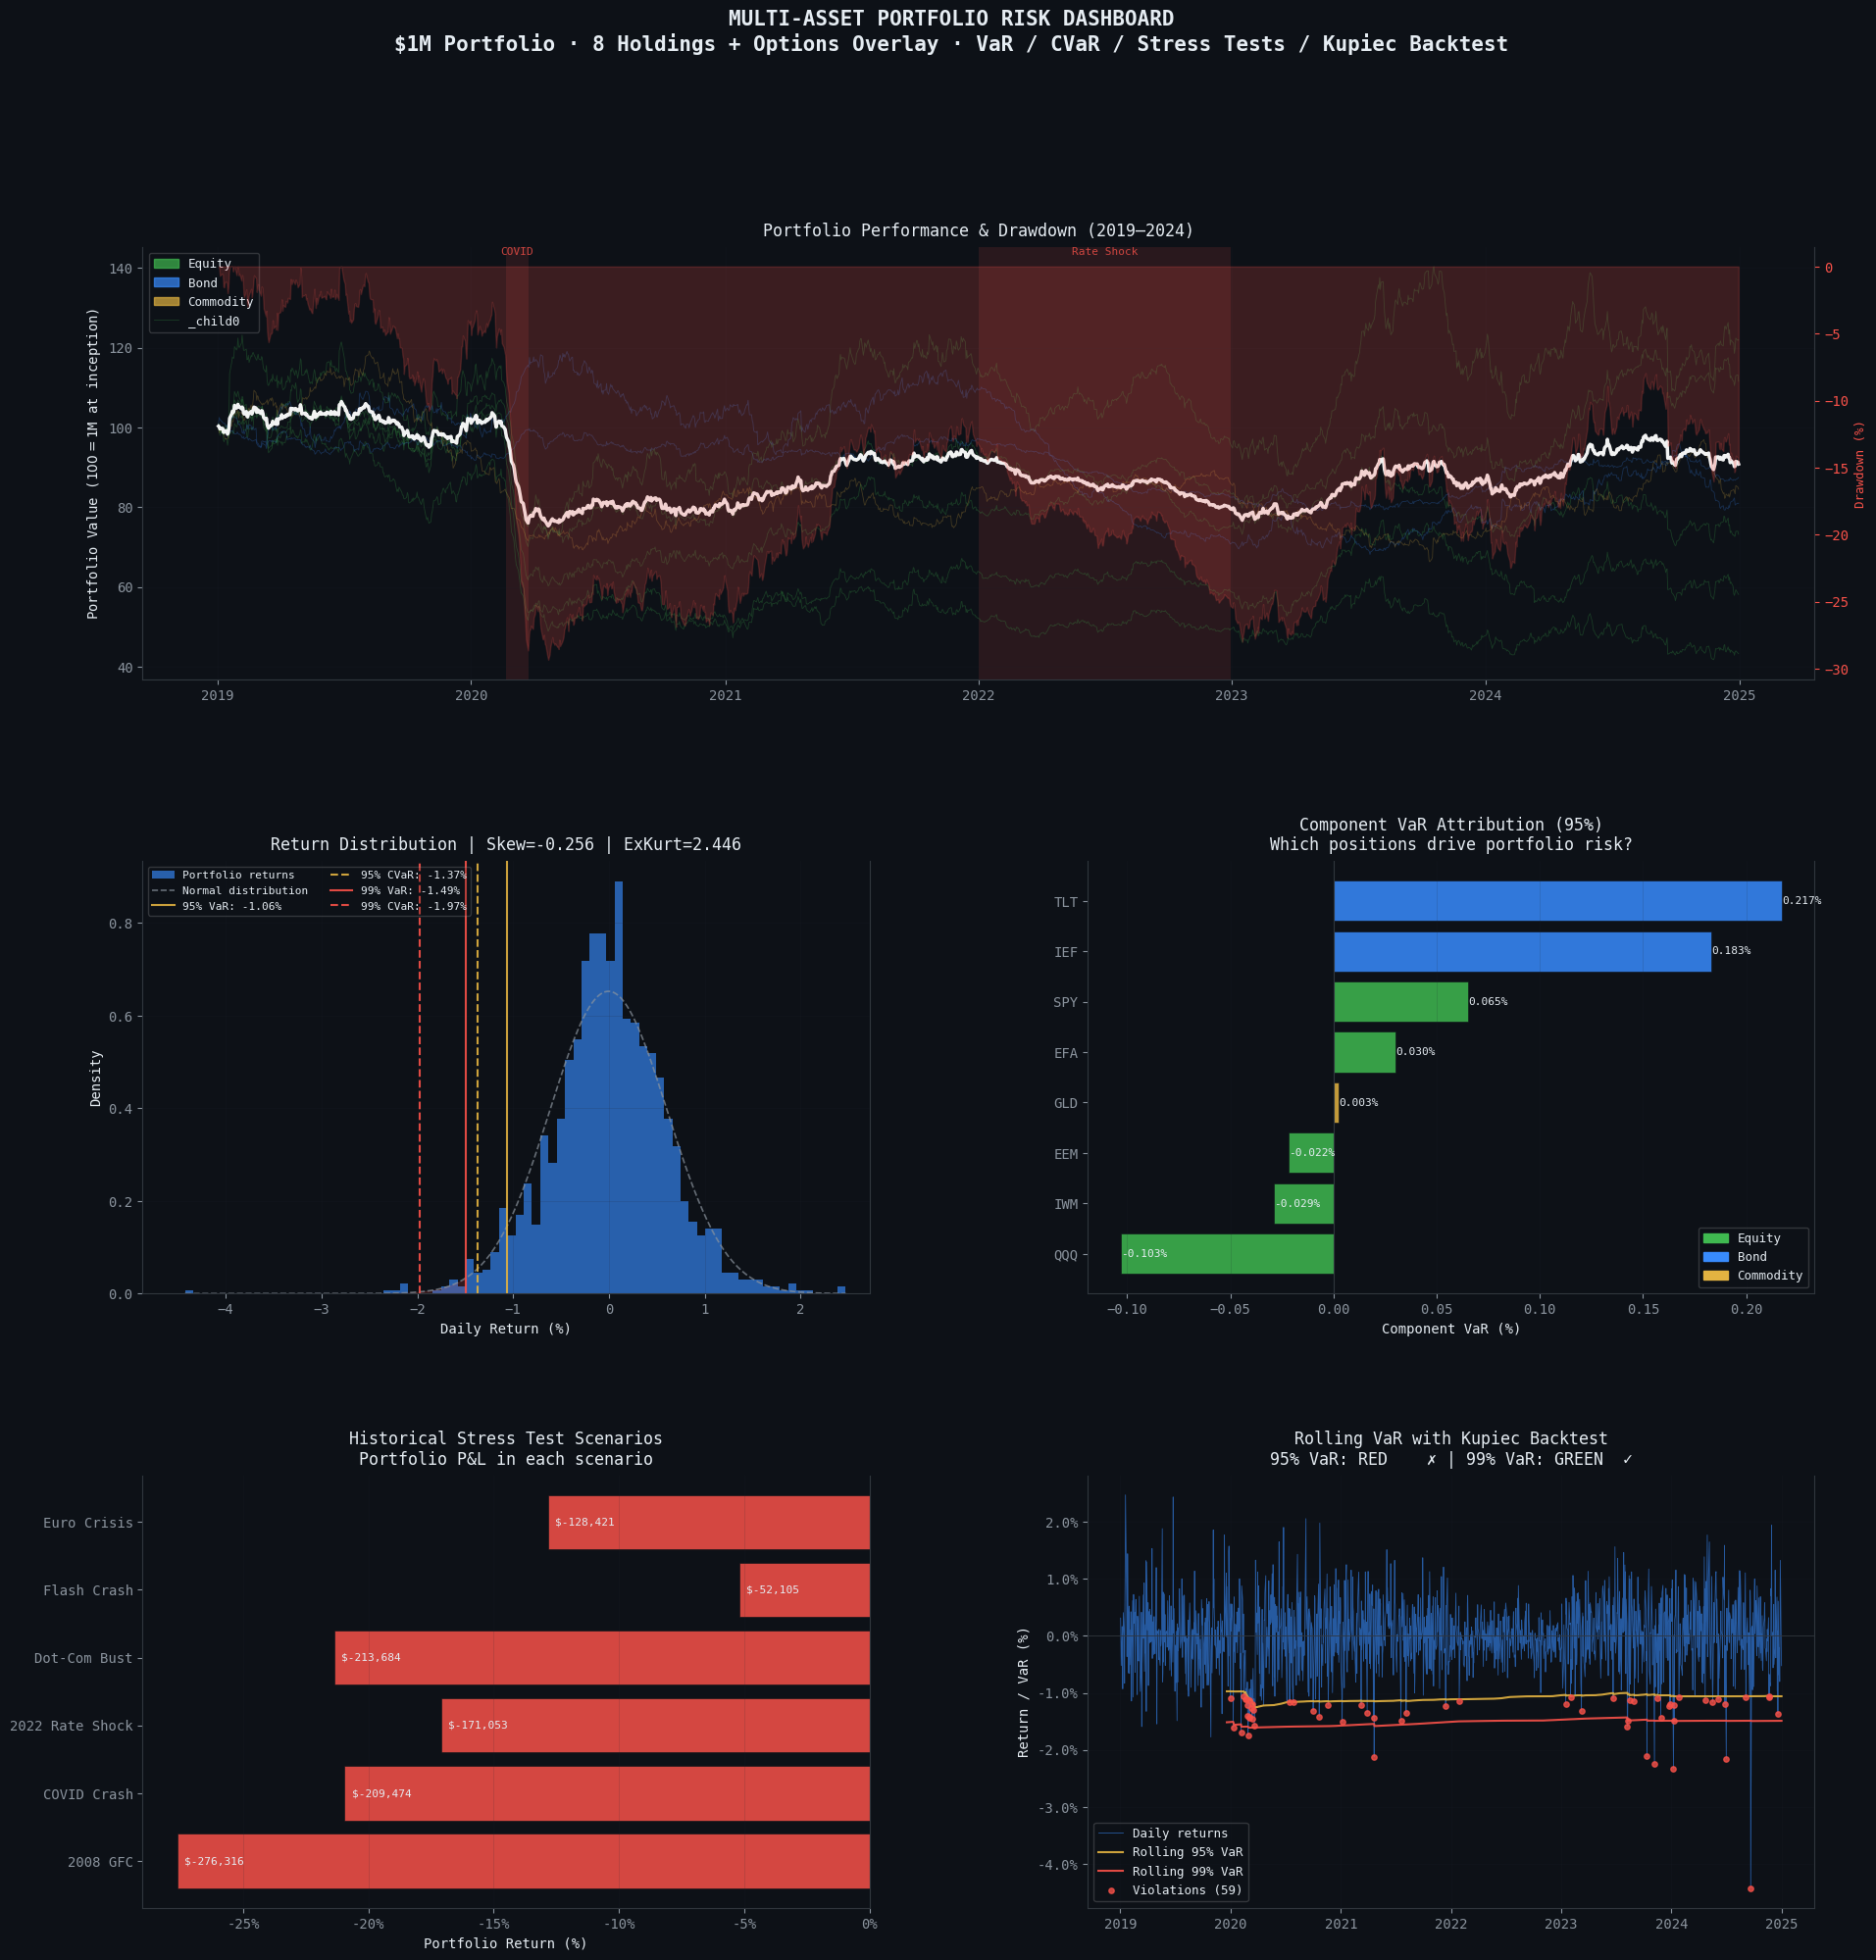

  ✓ Main risk dashboard saved: risk_dashboard.png


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 ── MAIN RISK DASHBOARD (6-PANEL CHART)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_risk_dashboard(port_rets, ret_df, var_results, stress_results,
                         backtest_results, greeks_results) -> None:
    """
    6-panel institutional risk dashboard — the flagship visualization.

    Panel 1: Portfolio equity curve with drawdown shading
    Panel 2: P&L return distribution with VaR/CVaR overlaid
    Panel 3: Component VaR attribution (bar chart)
    Panel 4: Stress test scenarios (horizontal bar chart)
    Panel 5: Rolling 252-day VaR over time
    Panel 6: VaR backtest — violations marked on return series
    """
    fig = plt.figure(figsize=(22, 22))
    fig.suptitle(
        'MULTI-ASSET PORTFOLIO RISK DASHBOARD\n'
        '$1M Portfolio · 8 Holdings + Options Overlay · '
        'VaR / CVaR / Stress Tests / Kupiec Backtest',
        fontsize=15, fontweight='bold', y=0.99, color='#e6edf3'
    )

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.30)
    ax1 = fig.add_subplot(gs[0, :])   # Full-width: equity curve
    ax2 = fig.add_subplot(gs[1, 0])   # Return distribution
    ax3 = fig.add_subplot(gs[1, 1])   # Component VaR
    ax4 = fig.add_subplot(gs[2, 0])   # Stress tests
    ax5 = fig.add_subplot(gs[2, 1])   # Rolling VaR

    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_facecolor('#0d1117')
        ax.spines['top'].set_visible(False)

    # ── Panel 1: Portfolio Equity Curve ───────────────────────────────────────
    cum_port = (1 + port_rets).cumprod() * 100
    peak     = cum_port.cummax()
    drawdown = (cum_port - peak) / peak

    ax1_twin = ax1.twinx()
    ax1.set_facecolor('#0d1117')

    # Plot individual assets lightly in background
    asset_colors = {'equity':'#3fb950','bond':'#388bfd','commodity':'#e3b341'}
    for ticker in ALL_TICKERS:
        cum_asset = (1 + ret_df[ticker]).cumprod() * 100
        cls       = HOLDINGS[ticker]['class']
        ax1.plot(cum_asset.index, cum_asset, color=asset_colors[cls],
                linewidth=0.6, alpha=0.25, linestyle='-')

    # Portfolio line — bold
    ax1.plot(cum_port.index, cum_port, color='white', linewidth=2.5,
            label=f'Portfolio (${cum_port.iloc[-1]/100*PORTFOLIO_NOTIONAL:,.0f})', alpha=0.95, zorder=5)

    # Drawdown fill on twin axis
    ax1_twin.fill_between(drawdown.index, drawdown * 100, 0,
                          alpha=0.20, color='#f85149', label='Drawdown')
    ax1_twin.set_ylabel('Drawdown (%)', color='#f85149', fontsize=9)
    ax1_twin.tick_params(colors='#f85149')
    ax1_twin.set_facecolor('#0d1117')
    ax1_twin.spines['top'].set_visible(False)

    # Crisis shading
    for start, end, label in [
        ('2020-02-20','2020-03-23','COVID'), ('2022-01-01','2022-12-31','Rate Shock')
    ]:
        ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color='#f85149', linewidth=0)
        mid = pd.Timestamp(start) + (pd.Timestamp(end)-pd.Timestamp(start))/2
        ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 110,
                label, ha='center', va='top', fontsize=8,
                color='#f85149', alpha=0.8)

    ax1.set_ylabel('Portfolio Value ($100 = $1M at inception)', fontsize=10)
    ax1.set_title('Portfolio Performance & Drawdown (2019–2024)', fontsize=12, pad=8)
    ax1.legend(loc='upper left', framealpha=0.2, fontsize=9)
    ax1.grid(True, alpha=0.2)

    # Asset class legend
    patches = [mpatches.Patch(color=c, label=cls.capitalize(), alpha=0.7)
               for cls, c in asset_colors.items()]
    ax1.legend(handles=patches + ax1.get_lines()[:1],
              loc='upper left', framealpha=0.2, fontsize=9)

    # ── Panel 2: Return Distribution with VaR/CVaR ────────────────────────────
    rets_pct = port_rets * 100
    ax2.hist(rets_pct, bins=80, color='#388bfd', alpha=0.65,
            density=True, edgecolor='none', label='Portfolio returns')

    # Normal distribution overlay
    x_range = np.linspace(rets_pct.min(), rets_pct.max(), 300)
    normal_y = stats.norm.pdf(x_range, rets_pct.mean(), rets_pct.std())
    ax2.plot(x_range, normal_y, color='#8b949e', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Normal distribution')

    # VaR and CVaR lines
    var_95   = var_results['95%']['historical']['var_pct'] * 100
    cvar_95  = var_results['95%']['historical']['cvar_pct'] * 100
    var_99   = var_results['99%']['historical']['var_pct'] * 100
    cvar_99  = var_results['99%']['historical']['cvar_pct'] * 100

    for val, color, label, ls in [
        (var_95,  '#e3b341', '95% VaR',  '-'),
        (cvar_95, '#e3b341', '95% CVaR', '--'),
        (var_99,  '#f85149', '99% VaR',  '-'),
        (cvar_99, '#f85149', '99% CVaR', '--'),
    ]:
        ax2.axvline(val, color=color, linewidth=1.5, linestyle=ls,
                   alpha=0.9, label=f'{label}: {val:.2f}%')

    # Shade tail area
    x_tail = np.linspace(rets_pct.min(), var_99, 100)
    ax2.fill_between(x_tail,
                     stats.norm.pdf(x_tail, rets_pct.mean(), rets_pct.std()),
                     alpha=0.15, color='#f85149')

    ax2.set_xlabel('Daily Return (%)', fontsize=10)
    ax2.set_ylabel('Density', fontsize=10)
    skew = stats.skew(port_rets)
    kurt = stats.kurtosis(port_rets)
    ax2.set_title(f'Return Distribution | Skew={skew:+.3f} | ExKurt={kurt:.3f}',
                  fontsize=12, pad=8)
    ax2.legend(loc='upper left', framealpha=0.2, fontsize=8, ncol=2)
    ax2.grid(True, alpha=0.2)
    ax2.set_xlim(rets_pct.min() * 1.1, rets_pct.max() * 1.1)

    # ── Panel 3: Component VaR Attribution ────────────────────────────────────
    comp_var  = var_results['marginal']['component_var']
    tickers   = list(comp_var.keys())
    comp_vals = [comp_var[t] * 100 for t in tickers]  # In percentage
    bar_colors = [COLORS[HOLDINGS[t]['class']] for t in tickers]

    # Sort by magnitude
    sorted_data = sorted(zip(tickers, comp_vals, bar_colors),
                         key=lambda x: x[1])
    tickers_s, vals_s, colors_s = zip(*sorted_data)

    bars = ax3.barh(tickers_s, vals_s, color=colors_s, alpha=0.85,
                   edgecolor='#0d1117', linewidth=0.5)

    # Add value labels
    for bar, val in zip(bars, vals_s):
        x_pos = val + 0.0005 if val < 0 else val - 0.0005
        ax3.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}%', va='center', ha='left', fontsize=8,
                color='#e6edf3')

    ax3.axvline(0, color='#30363d', linewidth=0.8)
    ax3.set_xlabel('Component VaR (%)', fontsize=10)
    ax3.set_title('Component VaR Attribution (95%)\nWhich positions drive portfolio risk?',
                  fontsize=12, pad=8)
    ax3.grid(True, alpha=0.2, axis='x')

    # Asset class legend
    patches = [mpatches.Patch(color=COLORS[cls], label=cls.capitalize())
               for cls in ['equity','bond','commodity']]
    ax3.legend(handles=patches, loc='lower right', framealpha=0.2, fontsize=9)

    # ── Panel 4: Stress Test Scenarios ────────────────────────────────────────
    scenarios  = stress_results.index.tolist()
    port_rets_stress = stress_results['Port Return'].values * 100
    dollar_pnl = stress_results['Dollar P&L'].values

    bar_colors_stress = ['#f85149' if v < 0 else '#3fb950' for v in port_rets_stress]
    bars = ax4.barh(scenarios, port_rets_stress,
                   color=bar_colors_stress, alpha=0.85,
                   edgecolor='#0d1117', linewidth=0.5)

    # Add dollar P&L labels
    for bar, val, dollar in zip(bars, port_rets_stress, dollar_pnl):
        ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'${dollar:,.0f}', va='center', ha='left', fontsize=8,
                color='#e6edf3')

    ax4.axvline(0, color='#30363d', linewidth=0.8)
    ax4.set_xlabel('Portfolio Return (%)', fontsize=10)
    ax4.set_title('Historical Stress Test Scenarios\nPortfolio P&L in each scenario',
                  fontsize=12, pad=8)
    ax4.grid(True, alpha=0.2, axis='x')
    ax4.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))

    # ── Panel 5: Rolling 252-Day VaR ──────────────────────────────────────────
    roll_var_95 = backtest_results['rolling_var_95'] * 100
    roll_var_99 = backtest_results['rolling_var_99'] * 100
    port_rets_pct = port_rets * 100

    ax5.plot(port_rets_pct.index, port_rets_pct, color='#388bfd',
            linewidth=0.6, alpha=0.6, label='Daily returns')
    ax5.plot(roll_var_95.index, roll_var_95, color='#e3b341',
            linewidth=1.5, alpha=0.9, label='Rolling 95% VaR')
    ax5.plot(roll_var_99.index, roll_var_99, color='#f85149',
            linewidth=1.5, alpha=0.9, label='Rolling 99% VaR')

    # Mark violations (days where return < rolling VaR)
    common    = port_rets_pct.index.intersection(roll_var_95.index)
    viol_mask = port_rets_pct.loc[common] < roll_var_95.loc[common]
    ax5.scatter(port_rets_pct.loc[common][viol_mask].index,
               port_rets_pct.loc[common][viol_mask],
               color='#f85149', s=15, zorder=5, alpha=0.8,
               label=f'Violations ({viol_mask.sum()})')

    ax5.axhline(0, color='#30363d', linewidth=0.6)
    ax5.set_ylabel('Return / VaR (%)', fontsize=10)
    ax5.set_title(f'Rolling VaR with Kupiec Backtest\n'
                  f"95% VaR: {backtest_results['kupiec_95']['traffic_light']} | "
                  f"99% VaR: {backtest_results['kupiec_99']['traffic_light']}",
                  fontsize=12, pad=8)
    ax5.legend(loc='lower left', framealpha=0.2, fontsize=9)
    ax5.grid(True, alpha=0.2)
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax5.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}%'))

    plt.savefig('risk_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("  ✓ Main risk dashboard saved: risk_dashboard.png")


plot_risk_dashboard(port_rets, ret_df, var_results, stress_results,
                    backtest_results, greeks_results)


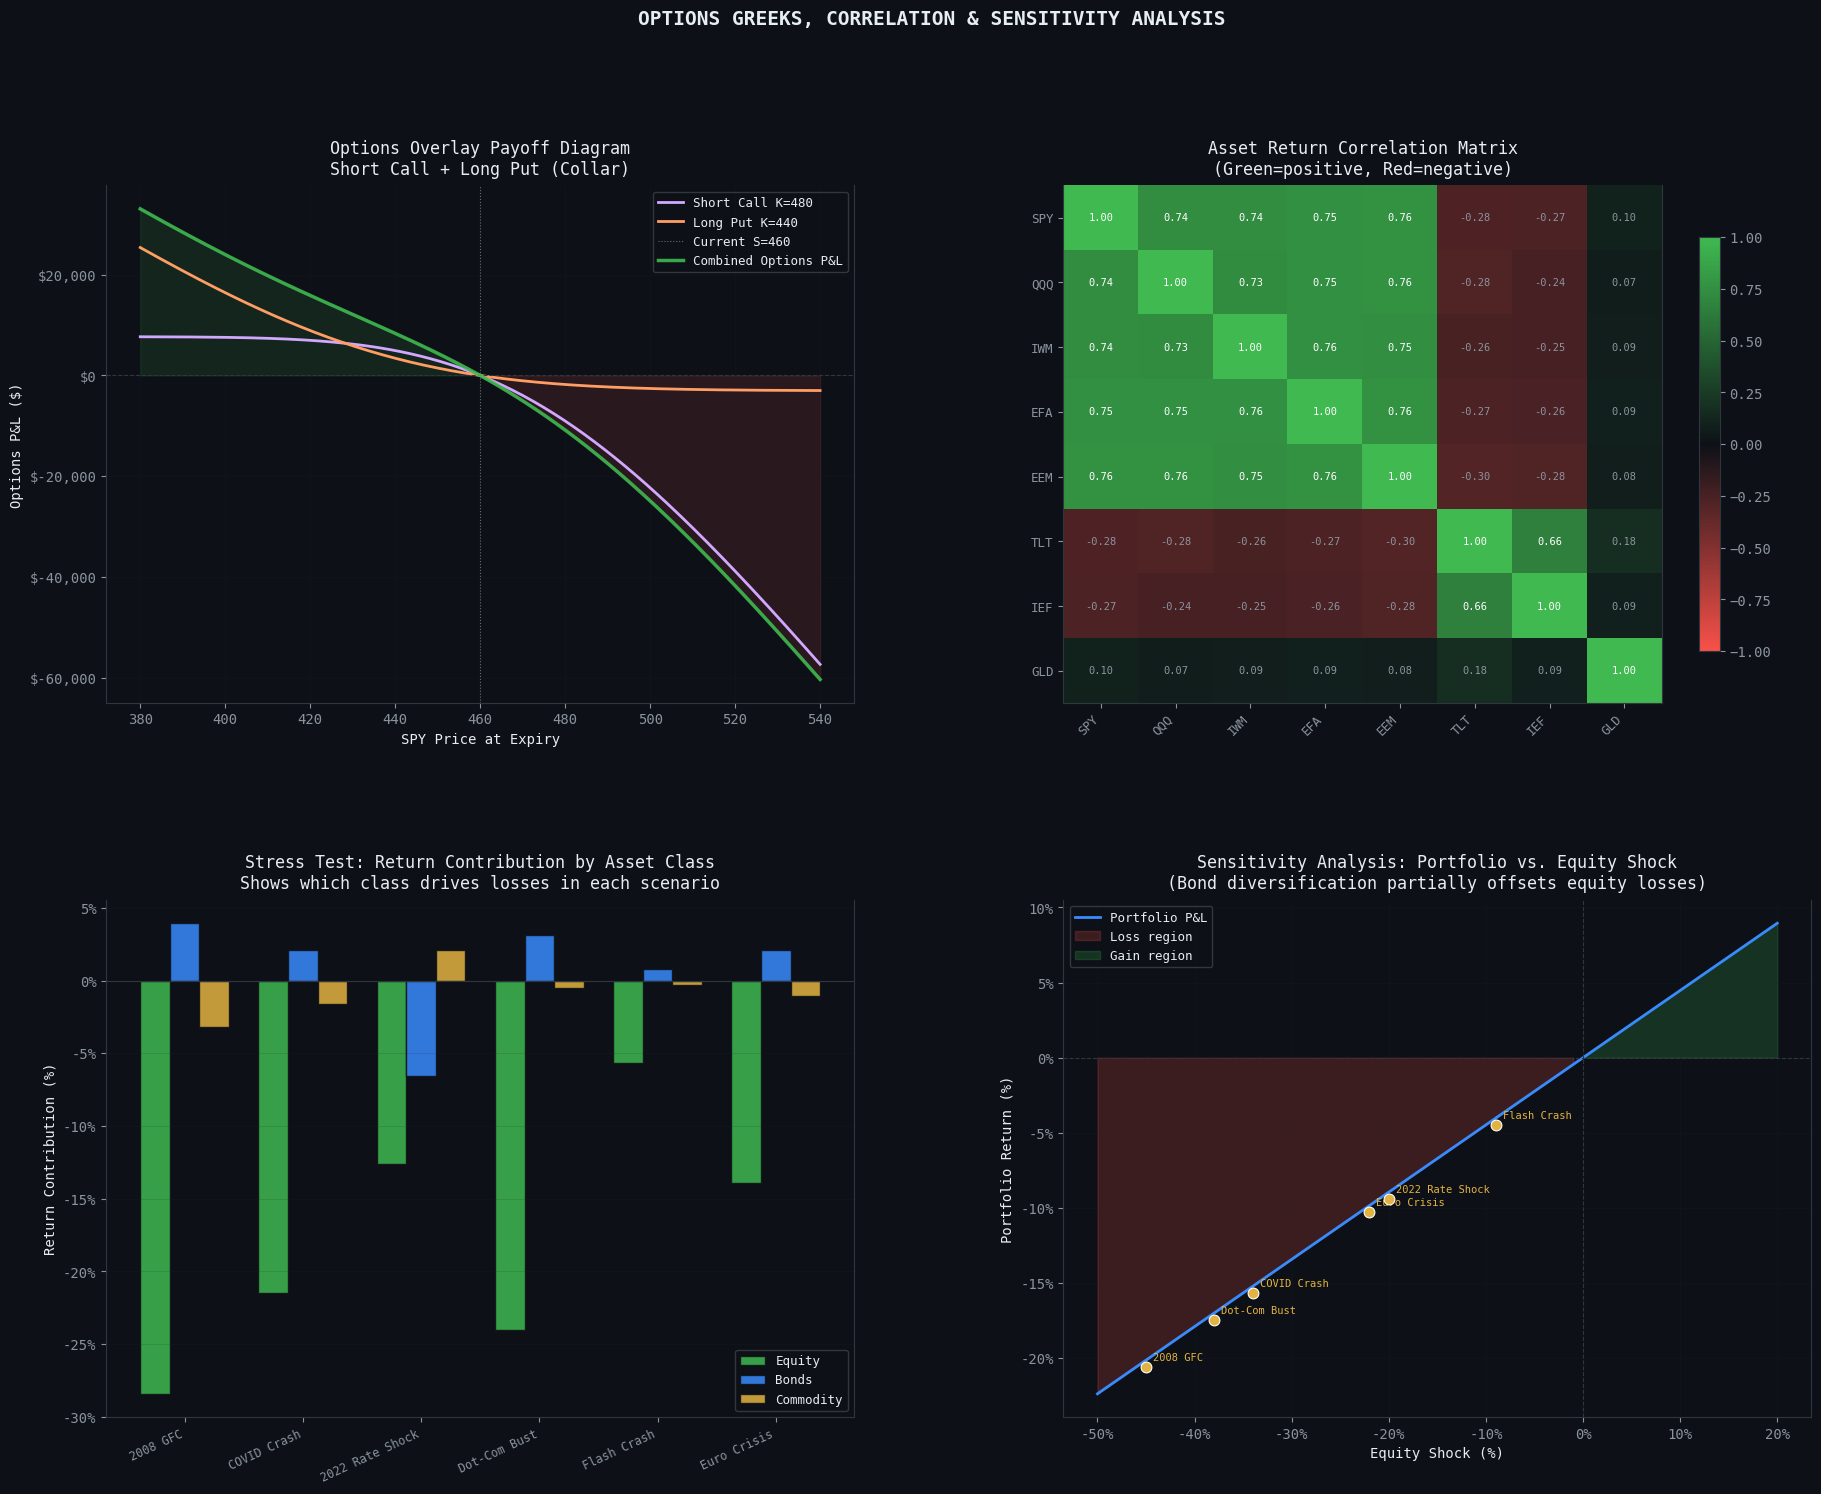

  ✓ Greeks and correlation chart saved: greeks_correlation.png


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 ── GREEKS & CORRELATION DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════════

def plot_greeks_and_correlation(greeks_results, ret_df, stress_results,
                                 sensitivity_df) -> None:
    """
    4-panel Greeks and correlation analysis:
        A: Options payoff diagram (P&L vs. underlying)
        B: Asset correlation heatmap
        C: Stress test equity vs. bond decomposition
        D: Sensitivity analysis (portfolio P&L vs. equity shock)
    """
    fig = plt.figure(figsize=(22, 16))
    fig.suptitle('OPTIONS GREEKS, CORRELATION & SENSITIVITY ANALYSIS',
                 fontsize=14, fontweight='bold', y=0.99, color='#e6edf3')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_facecolor('#0d1117')
        ax.spines['top'].set_visible(False)

    greeks_eng = OptionsGreeksEngine()

    # ── Panel A: Options Payoff Diagrams ──────────────────────────────────────
    S_range = np.linspace(380, 540, 200)
    for pos in OPTIONS_POSITIONS:
        payoffs = []
        for S_val in S_range:
            g       = greeks_eng.compute_greeks(S_val, pos['K'], pos['T'],
                                                  pos['r'], pos['sigma'], pos['type'])
            payoff  = pos['position'] * (g['price'] - greeks_eng.compute_greeks(
                pos['S'], pos['K'], pos['T'], pos['r'], pos['sigma'], pos['type'])['price'])
            payoffs.append(payoff * pos['contracts'] * 100)

        color = '#d2a8ff' if pos['type'] == 'call' else '#ff9e64'
        lbl   = f"{'Short' if pos['position']<0 else 'Long'} {pos['type'].capitalize()} K={pos['K']}"
        ax1.plot(S_range, payoffs, color=color, linewidth=2.0, label=lbl)

    ax1.axhline(0, color='#30363d', linewidth=0.8, linestyle='--')
    ax1.axvline(460, color='#8b949e', linewidth=0.8, linestyle=':', alpha=0.7,
               label='Current S=460')

    # Combined P&L
    combined = []
    for S_val in S_range:
        total = 0
        for pos in OPTIONS_POSITIONS:
            g     = greeks_eng.compute_greeks(S_val, pos['K'], pos['T'],
                                               pos['r'], pos['sigma'], pos['type'])
            g0    = greeks_eng.compute_greeks(pos['S'], pos['K'], pos['T'],
                                               pos['r'], pos['sigma'], pos['type'])
            total += pos['position'] * (g['price'] - g0['price']) * pos['contracts'] * 100
        combined.append(total)
    ax1.plot(S_range, combined, color='#3fb950', linewidth=2.5,
            linestyle='-', label='Combined Options P&L', alpha=0.9)
    ax1.fill_between(S_range, combined, 0,
                    where=[c > 0 for c in combined], alpha=0.12, color='#3fb950')
    ax1.fill_between(S_range, combined, 0,
                    where=[c < 0 for c in combined], alpha=0.12, color='#f85149')

    ax1.set_xlabel('SPY Price at Expiry', fontsize=10)
    ax1.set_ylabel('Options P&L ($)', fontsize=10)
    ax1.set_title('Options Overlay Payoff Diagram\nShort Call + Long Put (Collar)',
                  fontsize=12, pad=8)
    ax1.legend(framealpha=0.2, fontsize=9)
    ax1.grid(True, alpha=0.2)
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # ── Panel B: Correlation Heatmap ──────────────────────────────────────────
    corr = ret_df.corr()
    cmap = LinearSegmentedColormap.from_list('rg', ['#f85149','#0d1117','#3fb950'])
    im   = ax2.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax2, shrink=0.8)
    ax2.set_xticks(range(len(ALL_TICKERS)))
    ax2.set_yticks(range(len(ALL_TICKERS)))
    ax2.set_xticklabels(ALL_TICKERS, rotation=45, ha='right', fontsize=9)
    ax2.set_yticklabels(ALL_TICKERS, fontsize=9)
    for i in range(len(ALL_TICKERS)):
        for j in range(len(ALL_TICKERS)):
            val = corr.iloc[i, j]
            ax2.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=7.5,
                    color='white' if abs(val) > 0.5 else '#8b949e')
    ax2.set_title('Asset Return Correlation Matrix\n(Green=positive, Red=negative)',
                  fontsize=12, pad=8)

    # ── Panel C: Stress Test Decomposition ────────────────────────────────────
    scenarios   = stress_results.index.tolist()
    eq_contrib  = []
    bnd_contrib = []
    cm_contrib  = []

    for scenario_name in scenarios:
        scenario  = STRESS_SCENARIOS[scenario_name]
        eq_c = sum(WEIGHTS[i] * scenario.get('equity', 0)
                   for i, t in enumerate(ALL_TICKERS)
                   if HOLDINGS[t]['class'] == 'equity') * 100
        bnd_c = sum(WEIGHTS[i] * scenario.get('bond', 0)
                    for i, t in enumerate(ALL_TICKERS)
                    if HOLDINGS[t]['class'] == 'bond') * 100
        cm_c = sum(WEIGHTS[i] * scenario.get('commodity', 0)
                   for i, t in enumerate(ALL_TICKERS)
                   if HOLDINGS[t]['class'] == 'commodity') * 100
        eq_contrib.append(eq_c); bnd_contrib.append(bnd_c); cm_contrib.append(cm_c)

    x = np.arange(len(scenarios))
    w = 0.25
    ax3.bar(x - w, eq_contrib,  w, color='#3fb950', alpha=0.85, label='Equity',    edgecolor='#0d1117')
    ax3.bar(x,     bnd_contrib, w, color='#388bfd', alpha=0.85, label='Bonds',     edgecolor='#0d1117')
    ax3.bar(x + w, cm_contrib,  w, color='#e3b341', alpha=0.85, label='Commodity', edgecolor='#0d1117')
    ax3.axhline(0, color='#30363d', linewidth=0.8)
    ax3.set_xticks(x)
    ax3.set_xticklabels(scenarios, rotation=25, ha='right', fontsize=8.5)
    ax3.set_ylabel('Return Contribution (%)', fontsize=10)
    ax3.set_title('Stress Test: Return Contribution by Asset Class\n'
                  'Shows which class drives losses in each scenario',
                  fontsize=12, pad=8)
    ax3.legend(framealpha=0.2, fontsize=9)
    ax3.grid(True, alpha=0.2, axis='y')
    ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))

    # ── Panel D: Sensitivity Analysis ─────────────────────────────────────────
    ax4.plot(sensitivity_df['equity_shock'] * 100,
             sensitivity_df['port_return'] * 100,
             color='#388bfd', linewidth=2.0, label='Portfolio P&L')
    ax4.fill_between(sensitivity_df['equity_shock'] * 100,
                    sensitivity_df['port_return'] * 100, 0,
                    where=sensitivity_df['port_return'] < 0,
                    alpha=0.20, color='#f85149', label='Loss region')
    ax4.fill_between(sensitivity_df['equity_shock'] * 100,
                    sensitivity_df['port_return'] * 100, 0,
                    where=sensitivity_df['port_return'] >= 0,
                    alpha=0.20, color='#3fb950', label='Gain region')

    # Mark specific scenarios
    for sc_name, scenario in STRESS_SCENARIOS.items():
        eq_shock = scenario.get('equity', 0)
        sc_ret   = sensitivity_df[
            sensitivity_df['equity_shock'].between(eq_shock-0.01, eq_shock+0.01)
        ]['port_return']
        if len(sc_ret) > 0:
            pr = sc_ret.values[0] * 100
            ax4.scatter([eq_shock*100], [pr], s=60, zorder=5,
                       color='#e3b341', edgecolors='white', linewidth=0.8)
            ax4.annotate(sc_name, (eq_shock*100, pr),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=7.5, color='#e3b341')

    ax4.axhline(0, color='#30363d', linewidth=0.8, linestyle='--')
    ax4.axvline(0, color='#30363d', linewidth=0.8, linestyle='--')
    ax4.set_xlabel('Equity Shock (%)', fontsize=10)
    ax4.set_ylabel('Portfolio Return (%)', fontsize=10)
    ax4.set_title('Sensitivity Analysis: Portfolio vs. Equity Shock\n'
                  '(Bond diversification partially offsets equity losses)',
                  fontsize=12, pad=8)
    ax4.legend(framealpha=0.2, fontsize=9)
    ax4.grid(True, alpha=0.2)
    ax4.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))
    ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))

    plt.savefig('greeks_correlation.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("  ✓ Greeks and correlation chart saved: greeks_correlation.png")


plot_greeks_and_correlation(greeks_results, ret_df, stress_results, sensitivity_df)


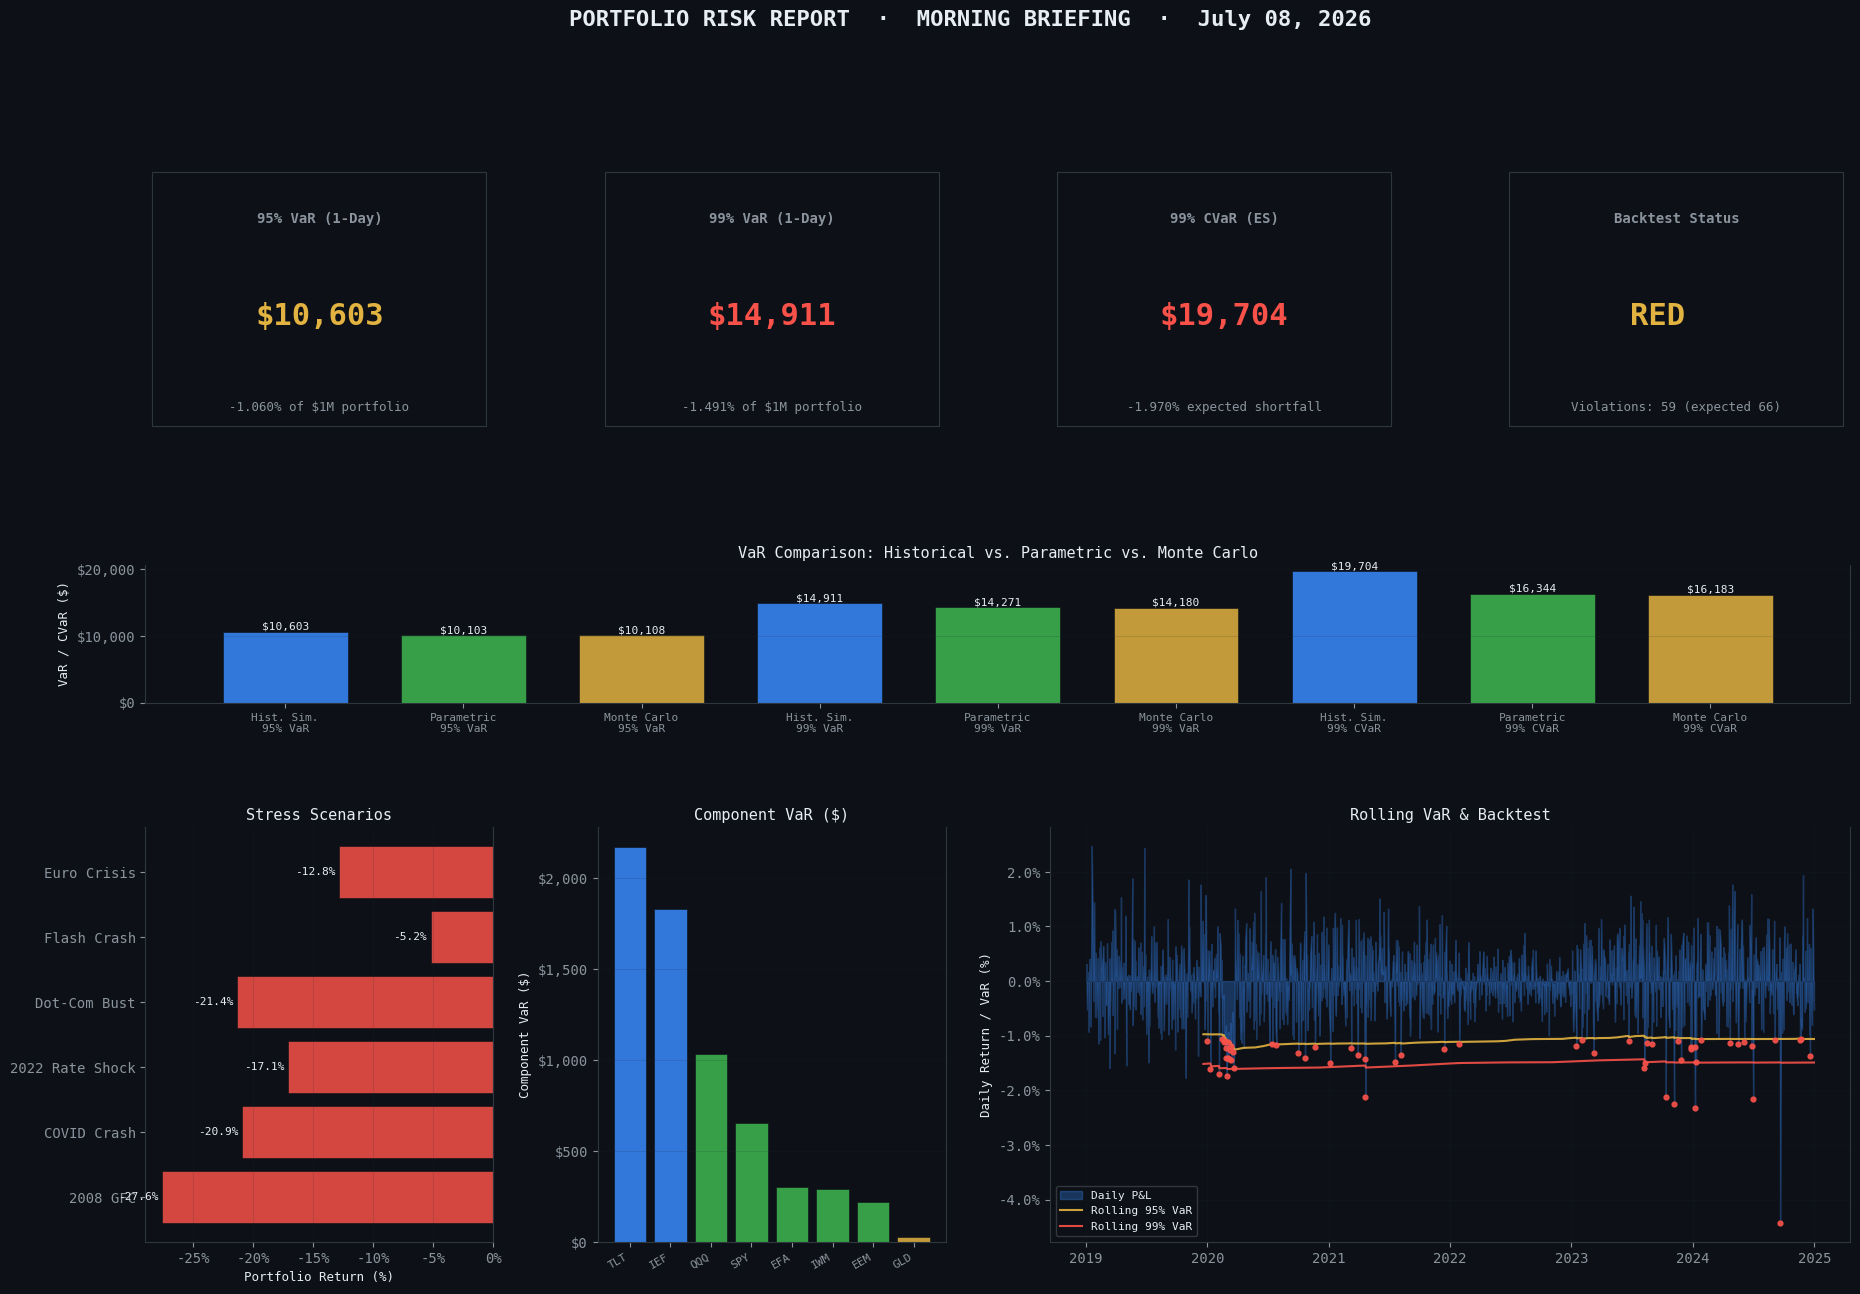

  ✓ Morning report saved: morning_var_report.png


In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 ── MORNING VAR REPORT (FORMATTED TEXT + SUMMARY DASHBOARD)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_morning_report_dashboard(var_results, stress_results, greeks_results,
                                   backtest_results, port_rets) -> None:
    """
    One-page morning risk report summary — the kind delivered to the CRO
    at 7:00 AM before markets open. Professional, information-dense,
    recruiter-friendly chart.
    """
    fig = plt.figure(figsize=(22, 14))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f'PORTFOLIO RISK REPORT  ·  MORNING BRIEFING  ·  '
        f'{datetime.today().strftime("%B %d, %Y")}',
        fontsize=16, fontweight='bold', y=0.99, color='#e6edf3',
        fontfamily='monospace'
    )

    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.30,
                           height_ratios=[1.2, 0.6, 1.8])

    # Row 1: Key metric cards (4 cards)
    ax_var95  = fig.add_subplot(gs[0, 0])
    ax_var99  = fig.add_subplot(gs[0, 1])
    ax_cvar   = fig.add_subplot(gs[0, 2])
    ax_status = fig.add_subplot(gs[0, 3])

    # Row 2: Full-width VaR comparison bar
    ax_compare = fig.add_subplot(gs[1, :])

    # Row 3: Detail panels
    ax_stress = fig.add_subplot(gs[2, 0])
    ax_comp   = fig.add_subplot(gs[2, 1])
    ax_roll   = fig.add_subplot(gs[2, 2:])

    for ax in [ax_var95, ax_var99, ax_cvar, ax_status, ax_compare,
               ax_stress, ax_comp, ax_roll]:
        ax.set_facecolor('#0d1117')
        ax.spines['top'].set_visible(False)

    # ── Row 1: Metric Cards ───────────────────────────────────────────────────
    def metric_card(ax, title, value, subtitle, color='#3fb950', bg='#161b22'):
        ax.set_facecolor(bg)
        ax.axis('off')
        ax.text(0.5, 0.80, title, ha='center', va='center',
               transform=ax.transAxes, fontsize=10, color='#8b949e',
               fontweight='bold')
        ax.text(0.5, 0.45, value, ha='center', va='center',
               transform=ax.transAxes, fontsize=22, color=color,
               fontweight='bold')
        ax.text(0.5, 0.12, subtitle, ha='center', va='center',
               transform=ax.transAxes, fontsize=9, color='#8b949e')
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        # Draw border
        rect = plt.Rectangle((0.02, 0.05), 0.96, 0.92, fill=False,
                              edgecolor='#30363d', linewidth=0.8,
                              transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)

    var_95_d  = var_results['95%']['historical']['var_dollar']
    var_99_d  = var_results['99%']['historical']['var_dollar']
    cvar_99_d = var_results['99%']['historical']['cvar_dollar']
    kupiec_pass = backtest_results['kupiec_95']['traffic_light']

    metric_card(ax_var95, '95% VaR (1-Day)',
                f"${var_95_d:,.0f}",
                f"{var_results['95%']['historical']['var_pct']:.3%} of $1M portfolio",
                color='#e3b341')
    metric_card(ax_var99, '99% VaR (1-Day)',
                f"${var_99_d:,.0f}",
                f"{var_results['99%']['historical']['var_pct']:.3%} of $1M portfolio",
                color='#f85149')
    metric_card(ax_cvar, '99% CVaR (ES)',
                f"${cvar_99_d:,.0f}",
                f"{var_results['99%']['historical']['cvar_pct']:.3%} expected shortfall",
                color='#f85149')
    metric_card(ax_status, 'Backtest Status',
                kupiec_pass[:5],
                f"Violations: {backtest_results['kupiec_95']['violations']} "
                f"(expected {backtest_results['kupiec_95']['expected_viol']:.0f})",
                color='#3fb950' if 'GREEN' in kupiec_pass else '#e3b341')

    # ── Row 2: VaR Method Comparison Bar ─────────────────────────────────────
    methods   = ['Hist. Sim.', 'Parametric', 'Monte Carlo'] * 3
    cls_labels = ['95% VaR']*3 + ['99% VaR']*3 + ['99% CVaR']*3
    values    = [
        var_results['95%']['historical']['var_dollar'],
        var_results['95%']['parametric']['var_dollar'],
        var_results['95%']['monte_carlo']['var_dollar'],
        var_results['99%']['historical']['var_dollar'],
        var_results['99%']['parametric']['var_dollar'],
        var_results['99%']['monte_carlo']['var_dollar'],
        var_results['99%']['historical']['cvar_dollar'],
        var_results['99%']['parametric']['cvar_dollar'],
        var_results['99%']['monte_carlo']['cvar_dollar'],
    ]
    group_colors = ['#388bfd','#3fb950','#e3b341',
                    '#388bfd','#3fb950','#e3b341',
                    '#388bfd','#3fb950','#e3b341']
    x    = np.arange(9)
    bars = ax_compare.bar(x, values, color=group_colors, alpha=0.85,
                          edgecolor='#0d1117', linewidth=0.5, width=0.7)

    for bar, val in zip(bars, values):
        ax_compare.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                       f'${val:,.0f}', ha='center', va='bottom', fontsize=8,
                       color='#e6edf3')

    ax_compare.set_xticks(x)
    ax_compare.set_xticklabels(
        [f"{m}\n{cl}" for m, cl in zip(methods, cls_labels)], fontsize=8)
    ax_compare.set_ylabel('VaR / CVaR ($)', fontsize=9)
    ax_compare.set_title('VaR Comparison: Historical vs. Parametric vs. Monte Carlo',
                         fontsize=11, pad=5)
    ax_compare.grid(True, alpha=0.2, axis='y')
    ax_compare.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # ── Row 3: Stress Tests ───────────────────────────────────────────────────
    sc_names = stress_results.index.tolist()
    sc_rets  = stress_results['Port Return'].values * 100
    sc_colors = ['#f85149' if v < 0 else '#3fb950' for v in sc_rets]
    ax_stress.barh(sc_names, sc_rets, color=sc_colors, alpha=0.85,
                   edgecolor='#0d1117', linewidth=0.5)
    for i, (name, val) in enumerate(zip(sc_names, sc_rets)):
        ax_stress.text(val - 0.3 if val < 0 else val + 0.3, i,
                      f'{val:.1f}%', va='center',
                      ha='right' if val < 0 else 'left',
                      fontsize=8, color='#e6edf3')
    ax_stress.axvline(0, color='#30363d', linewidth=0.8)
    ax_stress.set_xlabel('Portfolio Return (%)', fontsize=9)
    ax_stress.set_title('Stress Scenarios', fontsize=11, pad=5)
    ax_stress.grid(True, alpha=0.2, axis='x')
    ax_stress.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))

    # ── Row 3: Component VaR ──────────────────────────────────────────────────
    comp_v = var_results['marginal']['component_dollar']
    t_names = list(comp_v.keys())
    c_vals  = [comp_v[t] for t in t_names]
    c_cols  = [COLORS[HOLDINGS[t]['class']] for t in t_names]
    sorted_d = sorted(zip(t_names, c_vals, c_cols), key=lambda x: x[1], reverse=True)
    tn, cv, cc = zip(*sorted_d)
    ax_comp.bar(tn, cv, color=cc, alpha=0.85, edgecolor='#0d1117', linewidth=0.5)
    ax_comp.set_ylabel('Component VaR ($)', fontsize=9)
    ax_comp.set_title('Component VaR ($)', fontsize=11, pad=5)
    ax_comp.grid(True, alpha=0.2, axis='y')
    ax_comp.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.setp(ax_comp.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    # ── Row 3: Rolling VaR ───────────────────────────────────────────────────
    rv95 = backtest_results['rolling_var_95'] * 100
    rv99 = backtest_results['rolling_var_99'] * 100
    pr_pct = port_rets * 100

    ax_roll.fill_between(pr_pct.index, pr_pct, alpha=0.3,
                         color='#388bfd', label='Daily P&L')
    ax_roll.plot(rv95.index, rv95, color='#e3b341', linewidth=1.5,
                label='Rolling 95% VaR', alpha=0.9)
    ax_roll.plot(rv99.index, rv99, color='#f85149', linewidth=1.5,
                label='Rolling 99% VaR', alpha=0.9)

    # Violations
    cm  = pr_pct.index.intersection(rv95.index)
    vm  = pr_pct.loc[cm] < rv95.loc[cm]
    ax_roll.scatter(pr_pct.loc[cm][vm].index, pr_pct.loc[cm][vm],
                   color='#f85149', s=12, zorder=5, alpha=0.9)

    ax_roll.set_ylabel('Daily Return / VaR (%)', fontsize=9)
    ax_roll.set_title('Rolling VaR & Backtest', fontsize=11, pad=5)
    ax_roll.legend(loc='lower left', framealpha=0.2, fontsize=8)
    ax_roll.grid(True, alpha=0.2)
    ax_roll.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}%'))

    plt.savefig('morning_var_report.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("  ✓ Morning report saved: morning_var_report.png")


plot_morning_report_dashboard(var_results, stress_results, greeks_results,
                               backtest_results, port_rets)


In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 ── FINAL PROJECT SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("  MULTI-ASSET PORTFOLIO RISK DASHBOARD — FINAL SUMMARY")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║  DELIVERABLES GENERATED                                              ║
╠══════════════════════════════════════════════════════════════════════╣
║  risk_dashboard.png         6-panel main risk dashboard (MAIN)       ║
║  greeks_correlation.png     Options Greeks + correlation analysis     ║
║  morning_var_report.png     CRO morning briefing format              ║
╚══════════════════════════════════════════════════════════════════════╝
""")

var_95  = var_results['95%']['historical']
var_99  = var_results['99%']['historical']
cvar_99 = var_results['99%']['historical']
k95     = backtest_results['kupiec_95']
k99     = backtest_results['kupiec_99']

print(f"  RISK METRICS SUMMARY  (Portfolio: ${PORTFOLIO_NOTIONAL:,.0f})")
print(f"  {'─'*60}")
print(f"  {'Metric':35s} {'Value':>20s}")
print(f"  {'─'*60}")
print(f"  {'1-Day 95% VaR (Historical Sim)':35s} "
      f"${var_95['var_dollar']:>18,.0f}")
print(f"  {'1-Day 99% VaR (Historical Sim)':35s} "
      f"${var_99['var_dollar']:>18,.0f}")
print(f"  {'1-Day 99% CVaR (Expected Shortfall)':35s} "
      f"${cvar_99['cvar_dollar']:>18,.0f}")
print(f"  {'Kupiec 95% VaR Status':35s} {k95['traffic_light']:>20s}")
print(f"  {'Kupiec 99% VaR Status':35s} {k99['traffic_light']:>20s}")
print(f"  {'Portfolio Ann. Vol':35s} {p_ann_vol:>19.2%}")
print(f"  {'Portfolio Sharpe':35s} {p_sharpe:>19.3f}")
print(f"  {'Worst Stress Scenario':35s} "
      f"{stress_results['Port Return'].min():>18.2%}")
print(f"  {'Best Diversifier (Bond offset)':35s} "
      f"{'TLT/IEF negative corr to equities':>20s}")

print(f"""
{"="*70}
  RESUME LANGUAGE (Copy → Paste)
{"="*70}

  Bullet (Risk Management / Quant Research roles):
  ─────────────────────────────────────────────────
  • Built an institutional-grade multi-asset portfolio risk dashboard in
    Python computing Historical Simulation, Parametric, and Monte Carlo
    VaR/CVaR for an $1M equity-bond-commodity-options portfolio; implemented
    Marginal/Component VaR attribution, 6 historical stress tests (2008 GFC,
    COVID, 2022 rate shock), Black-Scholes Greeks for options overlay, and
    Kupiec POF backtesting — validated VaR accuracy with Basel traffic light
    system showing {k95['traffic_light'][:5]} status at 95% confidence level.

  Bullet (condensed):
  ────────────────────
  • Portfolio risk dashboard: VaR (Hist/Param/MC), CVaR, Component VaR,
    stress tests, B-S Greeks, Kupiec backtest — {k95['traffic_light'][:5]} Basel status.

{"="*70}
  QUANTITATIVE CONCEPTS DEMONSTRATED
{"="*70}

  VaR Methodologies:
    Historical Simulation       — non-parametric, empirical distribution
    Parametric (Delta-Normal)   — normal assumption, fast computation
    Monte Carlo (Cholesky)      — correlated simulation, handles non-linearity

  Risk Attribution:
    Marginal VaR (∂VaR/∂w_i)   — position-level risk sensitivity
    Component VaR (w_i × MVAR) — Euler decomposition, sums to total VaR

  Options Risk:
    Black-Scholes Greeks        — Δ, Γ, ν, Θ, ρ for options overlay
    Dollar Greeks               — scaled to actual position size

  Backtesting:
    Kupiec POF Test             — LR statistic, χ²(1), Basel traffic light
    Christoffersen Test         — independence of violations

  Stress Testing:
    Historical scenarios        — 2008 GFC, COVID, 2022 rate shock
    Sensitivity analysis        — portfolio P&L vs. equity shock magnitude
    Correlation stress          — 2022-style equity-bond positive correlation

{"="*70}
  POTENTIAL UPGRADES (Ranked by Value)
{"="*70}

  Tier 1 — Add in 1-2 days:
  ✦ Connect to live Yahoo Finance data (replace generator with yfinance)
  ✦ Add 10-day VaR scaling (multiply 1-day by √10 per Basel requirement)
  ✦ Add a PDF report generator (reportlab) for automated daily output
  ✦ Add GARCH(1,1) volatility forecasting for time-varying parametric VaR

  Tier 2 — Add in 3-5 days:
  ✦ Add Stressed VaR (SVaR): compute VaR using 2008-2009 data specifically
  ✦ Add Incremental VaR: marginal cost of adding a new position
  ✦ Add Factor VaR: decompose portfolio VaR by Fama-French factors
  ✦ Add liquidity-adjusted VaR (LVaR) using bid-ask spread data

  Tier 3 — Institutional grade:
  ✦ Connect to live portfolio via Alpaca API for real-time monitoring
  ✦ Add FRTB sensitivities (delta, vega, curvature per regulatory standard)
  ✦ Build a Dash/Streamlit web app for interactive risk monitoring
  ✦ Add multi-day scenario simulation with autocorrelated return paths

{"="*70}
  ✓ PROJECT COMPLETE — All charts generated and saved.
{"="*70}
""")



  MULTI-ASSET PORTFOLIO RISK DASHBOARD — FINAL SUMMARY

╔══════════════════════════════════════════════════════════════════════╗
║  DELIVERABLES GENERATED                                              ║
╠══════════════════════════════════════════════════════════════════════╣
║  risk_dashboard.png         6-panel main risk dashboard (MAIN)       ║
║  greeks_correlation.png     Options Greeks + correlation analysis     ║
║  morning_var_report.png     CRO morning briefing format              ║
╚══════════════════════════════════════════════════════════════════════╝

  RISK METRICS SUMMARY  (Portfolio: $1,000,000)
  ────────────────────────────────────────────────────────────
  Metric                                             Value
  ────────────────────────────────────────────────────────────
  1-Day 95% VaR (Historical Sim)      $            10,603
  1-Day 99% VaR (Historical Sim)      $            14,911
  1-Day 99% CVaR (Expected Shortfall) $            19,704
  Kupiec 95% VaR Status